In [77]:
import json
import os.path
import re
import yaml
import pandas as pd
import matplotlib.pyplot as plt

CSV_PERSON_FILE_SIZE = 880941057      # bytes
JSON_PERSON_FILE_SIZE = 1300941057    # bytes

CSV_BASE_LABEL = "CSV Baseline"
CSV_NO_COPY_LABEL = "CSV VarEl"
JSON_BASE_LABEL = "JSON Baseline"
JSON_NO_COPY_LABEL = "JSON VarEl"

SUITE_ORDER = [CSV_BASE_LABEL, CSV_NO_COPY_LABEL, JSON_BASE_LABEL, JSON_NO_COPY_LABEL]
SUITE_COLORS = {
    CSV_BASE_LABEL: "#0072B2",
    CSV_NO_COPY_LABEL: "#009E73",
    JSON_BASE_LABEL: "#D55E00",
    JSON_NO_COPY_LABEL: "#CC79A7",
}
SUITE_HATCH = {
    CSV_BASE_LABEL: "",
    CSV_NO_COPY_LABEL: "//",
    JSON_BASE_LABEL: "",
    JSON_NO_COPY_LABEL: "//",
}

def shorten_query(q):
    q = re.sub(r"\s+INTO\s+\w+", "", q, flags=re.IGNORECASE)
    q = re.sub(r'VARSIZED\("([^"]+)"\)', r'"\1"', q)
    q = re.sub(r'INT32\((\d+)\)', r'\1', q)
    q = re.sub(r'FLOAT64\(([\d.]+)\)', r'\1', q)
    return re.sub(r'\s+', ' ', q).strip()

def load_query_text(query_file):
    with open(query_file) as f:
        return yaml.safe_load(f)["query"]

def get_file_size(suite_name):
    if "json" in suite_name.lower():
        return JSON_PERSON_FILE_SIZE
    return CSV_PERSON_FILE_SIZE

def load_suite(filepath, suite_name, query_dir):
    with open(filepath) as f:
        data = json.load(f)
    file_size = get_file_size(suite_name)
    rows = []
    for r in data:
        if r.get("state") != "Stopped":
            continue
        exec_time = (r["stop_time_ms"] - r["start_time_ms"]) / 1000.0
        if exec_time <= 0:
            continue
        query_file = os.path.join(query_dir, os.path.basename(r["query_file"]))
        query_text = shorten_query(load_query_text(query_file))
        rows.append({
            "suite": suite_name,
            "query": query_text,
            "threads": r["threads_number"],
            "exec_time_s": exec_time,
            "throughput_MBs": file_size / exec_time / (1024 * 1024),
        })
    return rows

rows = []
rows += load_suite("results/baseline_results_1776374217.json", CSV_BASE_LABEL, "queries-evaluated")
rows += load_suite("results/optimized_results_1776375022.json", CSV_NO_COPY_LABEL, "queries-evaluated")
rows += load_suite("results/baseline-json_results_1776489253.json", JSON_BASE_LABEL, "queries-json-evaluated")
rows += load_suite("results/optimized-json_results_1776490691.json", JSON_NO_COPY_LABEL, "queries-json-evaluated")

# rows += load_suite("results/baseline_results_1776507542.json", CSV_BASE_LABEL, "queries-evaluated")
# rows += load_suite("results/optimized_results_1776507806.json", CSV_NO_COPY_LABEL, "queries-evaluated")
# rows += load_suite("results/baseline-json_results_1776512610.json", JSON_BASE_LABEL, "queries-json-evaluated")
# rows += load_suite("results/optimized-json_results_1776513095.json", JSON_NO_COPY_LABEL, "queries-json-evaluated")

rows += load_suite("results/baseline_results_1776507542.json", CSV_BASE_LABEL, "queries-evaluated")
rows += load_suite("results/baseline-json_results_1776512610.json", JSON_BASE_LABEL, "queries-evaluated")
rows += load_suite("results/optimized_results_1776507806.json", CSV_NO_COPY_LABEL, "queries-evaluated")
rows += load_suite("results/optimized-json_results_1776513095.json", JSON_NO_COPY_LABEL, "queries-json-evaluated")


df = pd.DataFrame(rows)
df = df[df["threads"] != 48].reset_index(drop=True)
print(f"Records: {len(df)}")
print(f"Suites: {sorted(df['suite'].unique())}")
print(f"Threads: {sorted(df['threads'].unique())}")
print(f"Queries: {sorted(df['query'].unique())}")
df

Records: 960
Suites: ['CSV Baseline', 'CSV VarEl', 'JSON Baseline', 'JSON VarEl']
Threads: [np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(32), np.int64(64)]
Queries: ['SELECT * FROM PERSON', 'SELECT CREDIT_CARD FROM PERSON', 'SELECT EXTRA FROM PERSON', 'SELECT ID FROM PERSON WHERE CITY == "redmond" AND STATE == "wy"']


,suite,query,threads,exec_time_s,throughput_MBs
0,CSV Baseline,SELECT EXTRA FROM PERSON,2,4.020,208.987776
1,CSV Baseline,SELECT EXTRA FROM PERSON,2,3.985,210.823302
2,CSV Baseline,SELECT EXTRA FROM PERSON,2,4.281,196.246405
3,CSV Baseline,SELECT EXTRA FROM PERSON,2,3.905,215.142346
4,CSV Baseline,SELECT EXTRA FROM PERSON,2,3.778,222.374500
...,...,...,...,...,...
955,JSON VarEl,SELECT CREDIT_CARD FROM PERSON,64,1.553,798.888650
956,JSON VarEl,SELECT CREDIT_CARD FROM PERSON,64,1.495,829.882323
957,JSON VarEl,SELECT CREDIT_CARD FROM PERSON,64,1.575,787.729570
958,JSON VarEl,SELECT CREDIT_CARD FROM PERSON,64,1.723,720.066206


wrote plots/varsized_copy_throughput_q1.pdf


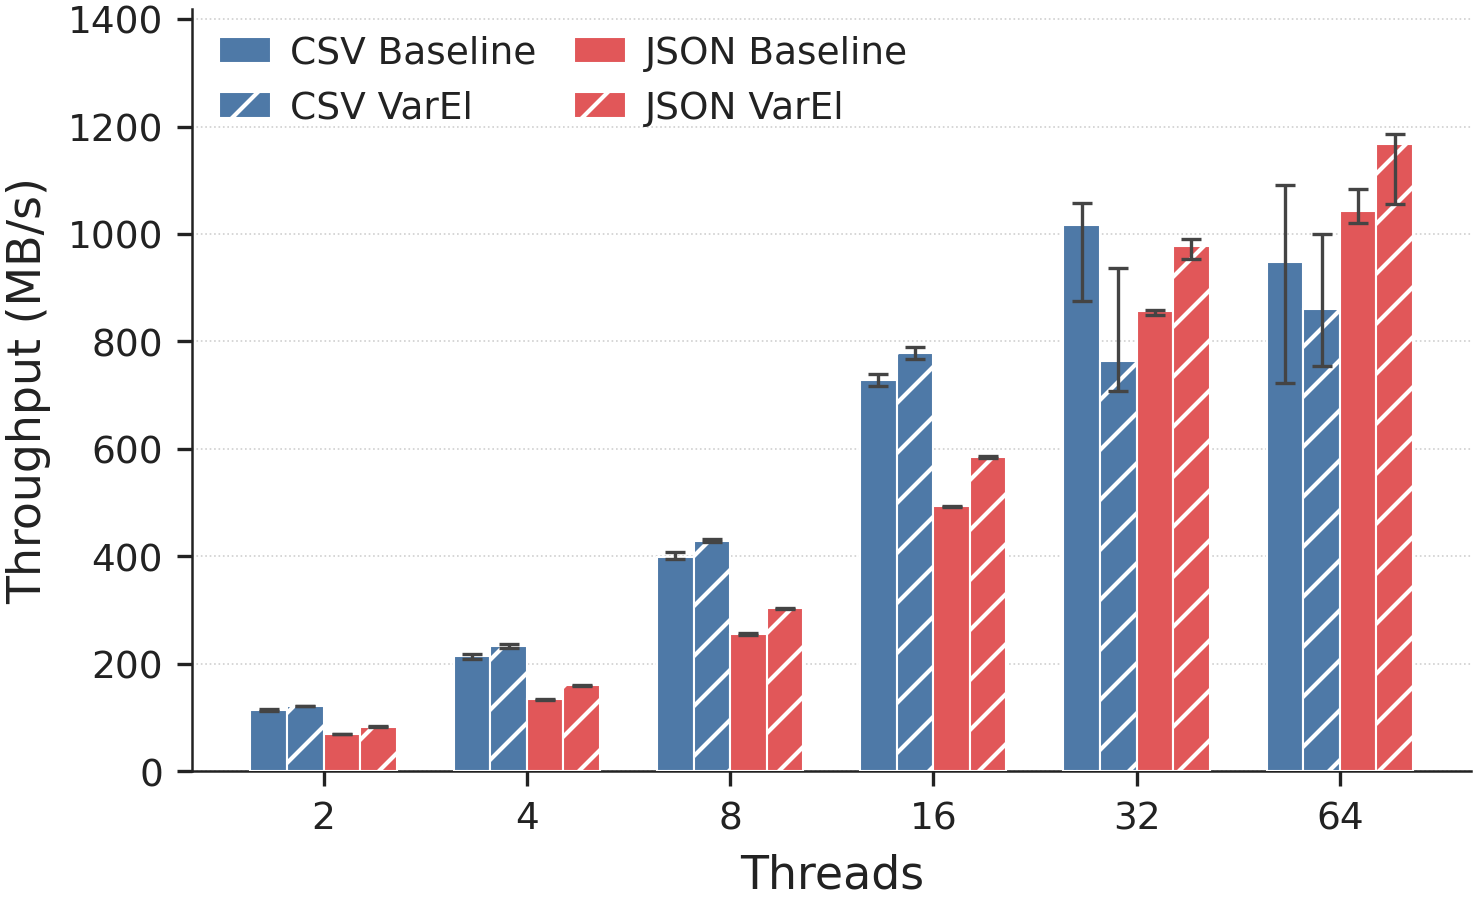

wrote plots/varsized_copy_throughput_q2.pdf


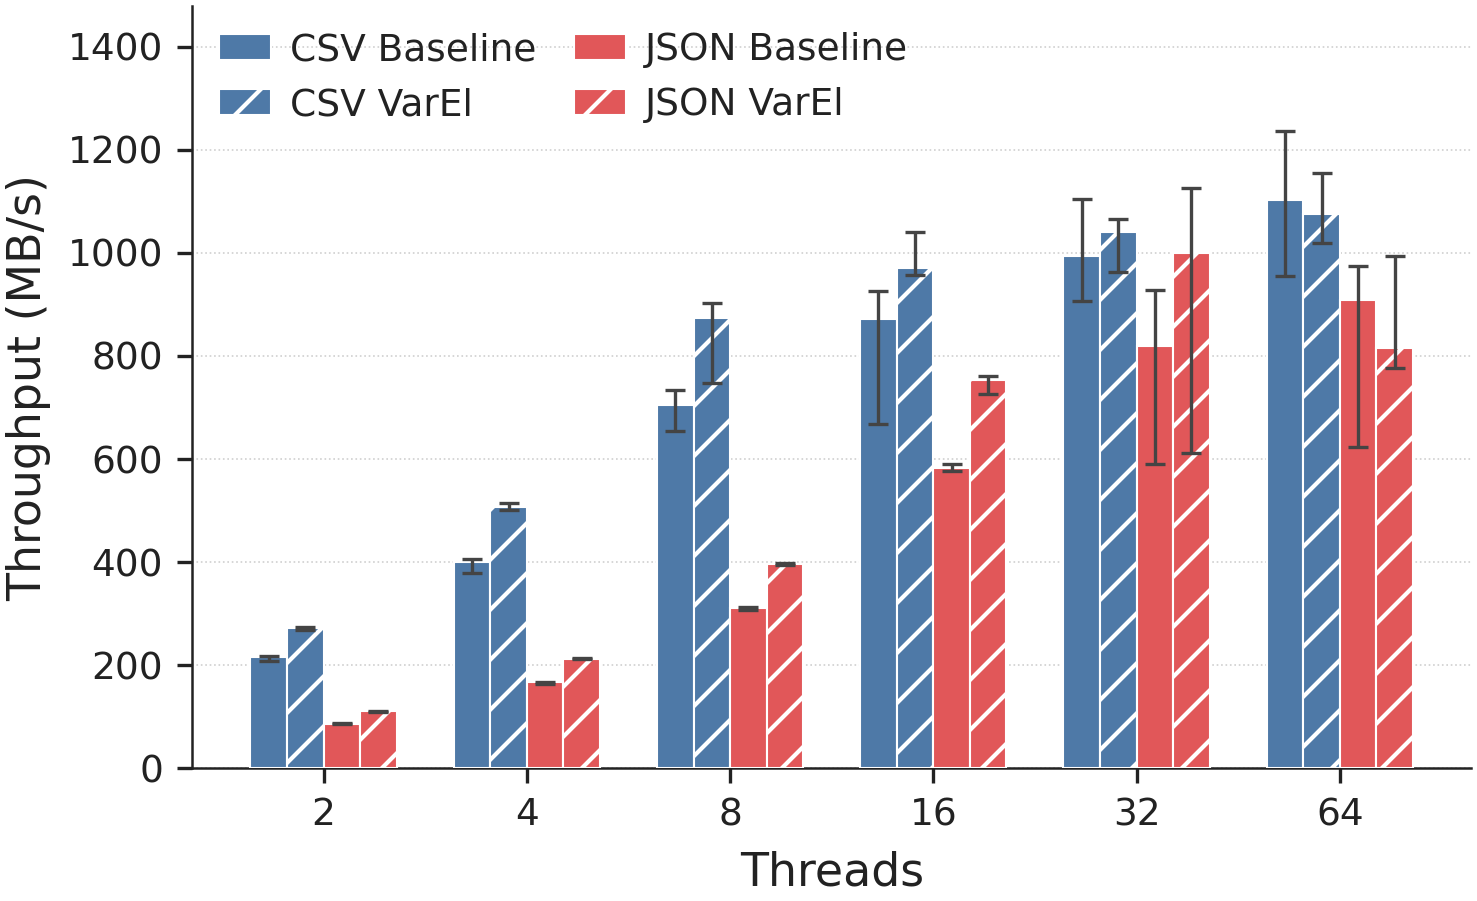

wrote plots/varsized_copy_throughput_q3.pdf


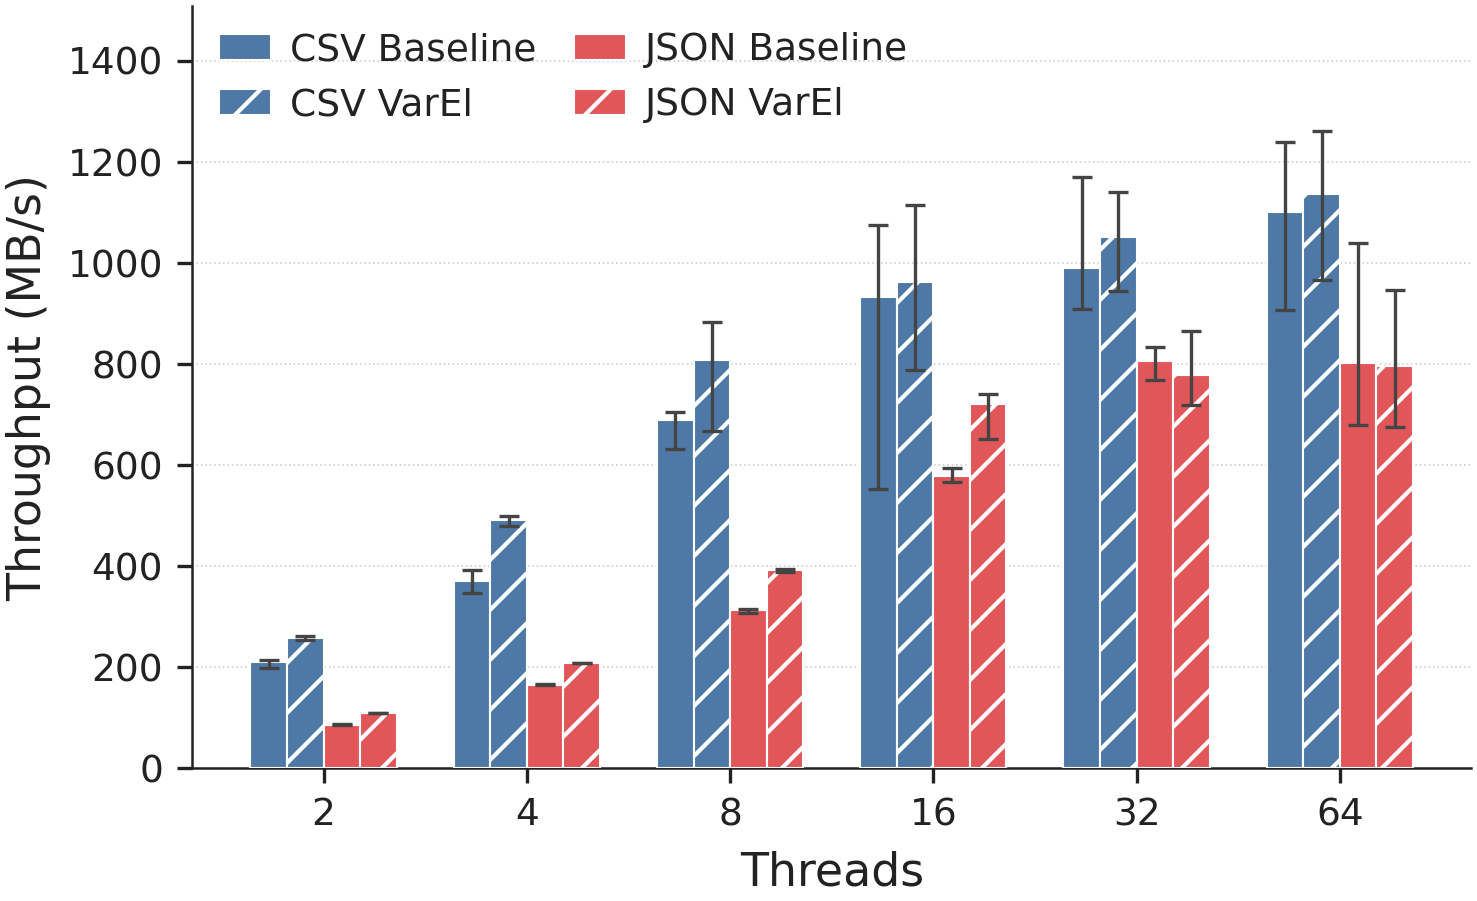

wrote plots/varsized_copy_throughput_q4.pdf


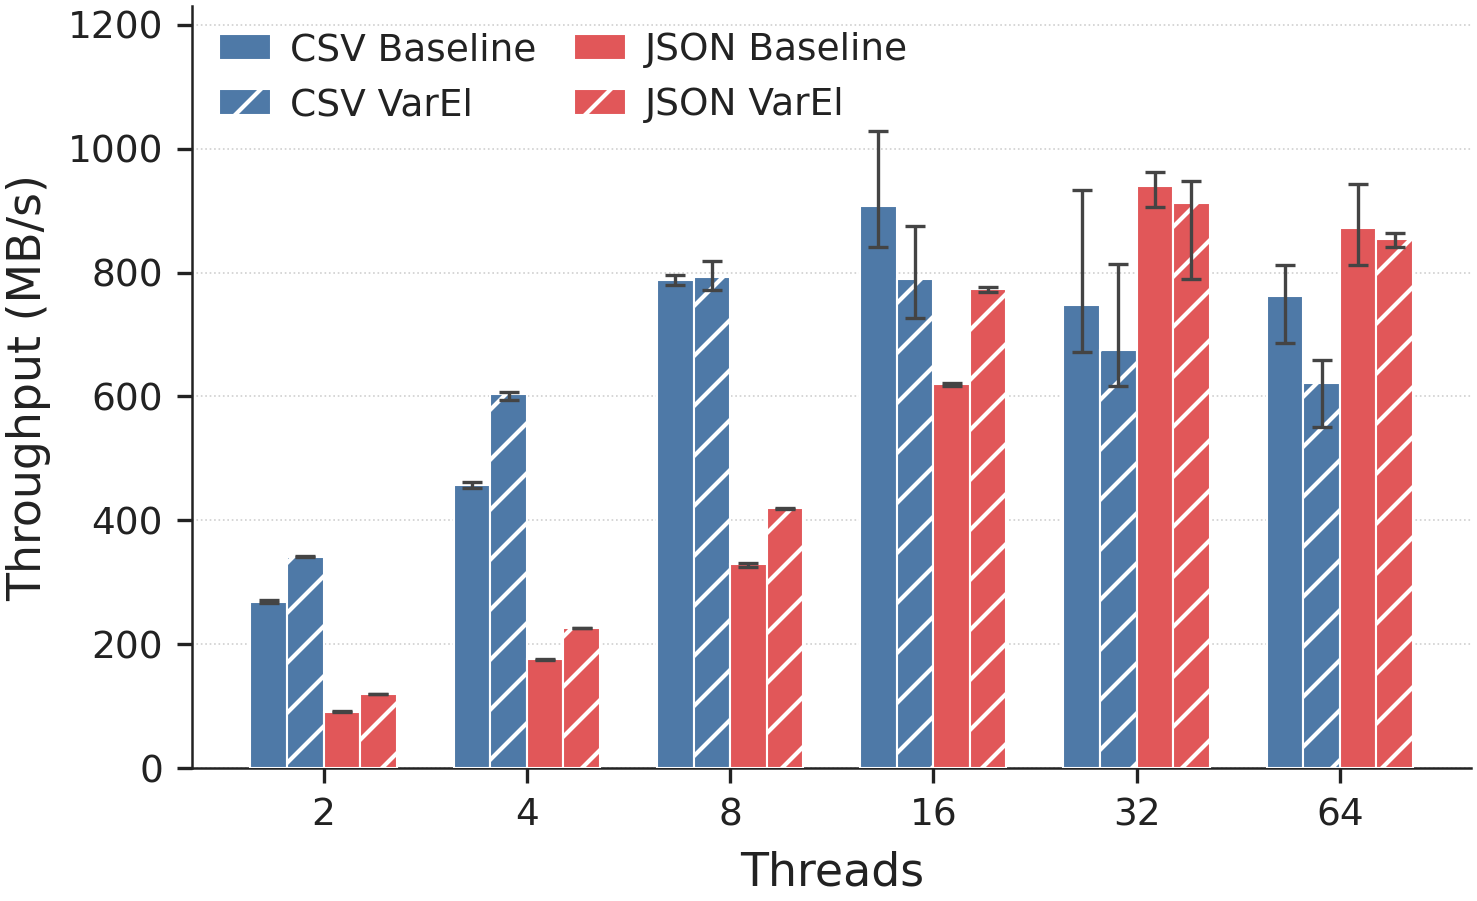

In [78]:
# Grouped bar chart: median throughput with IQR error bars, one standalone plot per query
import os
import re
import numpy as np
import matplotlib as mpl

PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

thesis_rc = {
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica", "Liberation Sans"],
    "font.size": 10,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "#222222",
    "axes.labelcolor": "#222222",
    "axes.titlecolor": "#222222",
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "axes.linewidth": 0.6,
    "axes.edgecolor": "#222222",
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.frameon": False,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
}

queries = sorted(df["query"].unique())
query_labels = {q: f"Q{i + 1}" for i, q in enumerate(queries)}
suites = SUITE_ORDER
suite_colors = {
    CSV_BASE_LABEL: "#4e79a7",
    CSV_NO_COPY_LABEL: "#4e79a7",
    JSON_BASE_LABEL: "#e15759",
    JSON_NO_COPY_LABEL: "#e15759",
}
suite_hatch = {
    CSV_BASE_LABEL: "",
    CSV_NO_COPY_LABEL: "//",
    JSON_BASE_LABEL: "",
    JSON_NO_COPY_LABEL: "//",
}
thread_counts = sorted(df["threads"].unique())
n_suites = len(suites)
bar_width = 0.18
x = np.arange(len(thread_counts))

query_file_labels = {
    q: re.sub(r"[^a-z0-9]+", "_", query_labels[q].lower()).strip("_")
    for q in queries
}

stats = (
    df.groupby(["query", "suite", "threads"])["throughput_MBs"]
    .agg(q1=lambda s: s.quantile(0.25), median="median", q3=lambda s: s.quantile(0.75))
    .reset_index()
)

with mpl.rc_context(thesis_rc):
    for q in queries:
        fig, ax = plt.subplots(figsize=(5.5, 3.3), dpi=300)

        for j, suite in enumerate(suites):
            subset = (
                stats[(stats["query"] == q) & (stats["suite"] == suite)]
                .set_index("threads")
                .reindex(thread_counts)
            )
            median = subset["median"].to_numpy(dtype=float)
            q1 = subset["q1"].to_numpy(dtype=float)
            q3 = subset["q3"].to_numpy(dtype=float)
            yerr = np.vstack([median - q1, q3 - median])
            offset = (j - (n_suites - 1) / 2) * bar_width
            ax.bar(
                x + offset,
                median,
                bar_width,
                label=suite,
                color=suite_colors[suite],
                edgecolor="#ffffff",
                linewidth=0.5,
                hatch=suite_hatch[suite],
                yerr=yerr,
                error_kw={"elinewidth": 0.8, "ecolor": "#444444", "capsize": 2.5, "capthick": 0.8},
                zorder=3,
            )

        ax.set_xlabel("Threads")
        ax.set_ylabel("Throughput (MB/s)")
        ax.set_xticks(x)
        ax.set_xticklabels(thread_counts)
        ax.set_ylim(0, ax.get_ylim()[1] * 1.14)
        ax.grid(True, axis="y", linestyle=":", linewidth=0.4, alpha=0.6, zorder=0)
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.legend(
            loc="upper left",
            ncol=2,
            columnspacing=1.0,
            handlelength=1.4,
            handletextpad=0.5,
            borderaxespad=0.3,
        )

        out = os.path.join(
            PLOTS_DIR,
            f"varsized_copy_throughput_{query_file_labels[q]}.pdf",
        )
        fig.savefig(out)
        print(f"wrote {out}")
        plt.show()


### Throughput Variance Variants

Notebook-only comparison plots for four compact ways to show throughput and variance together. These cells only display figures and do not save any files.


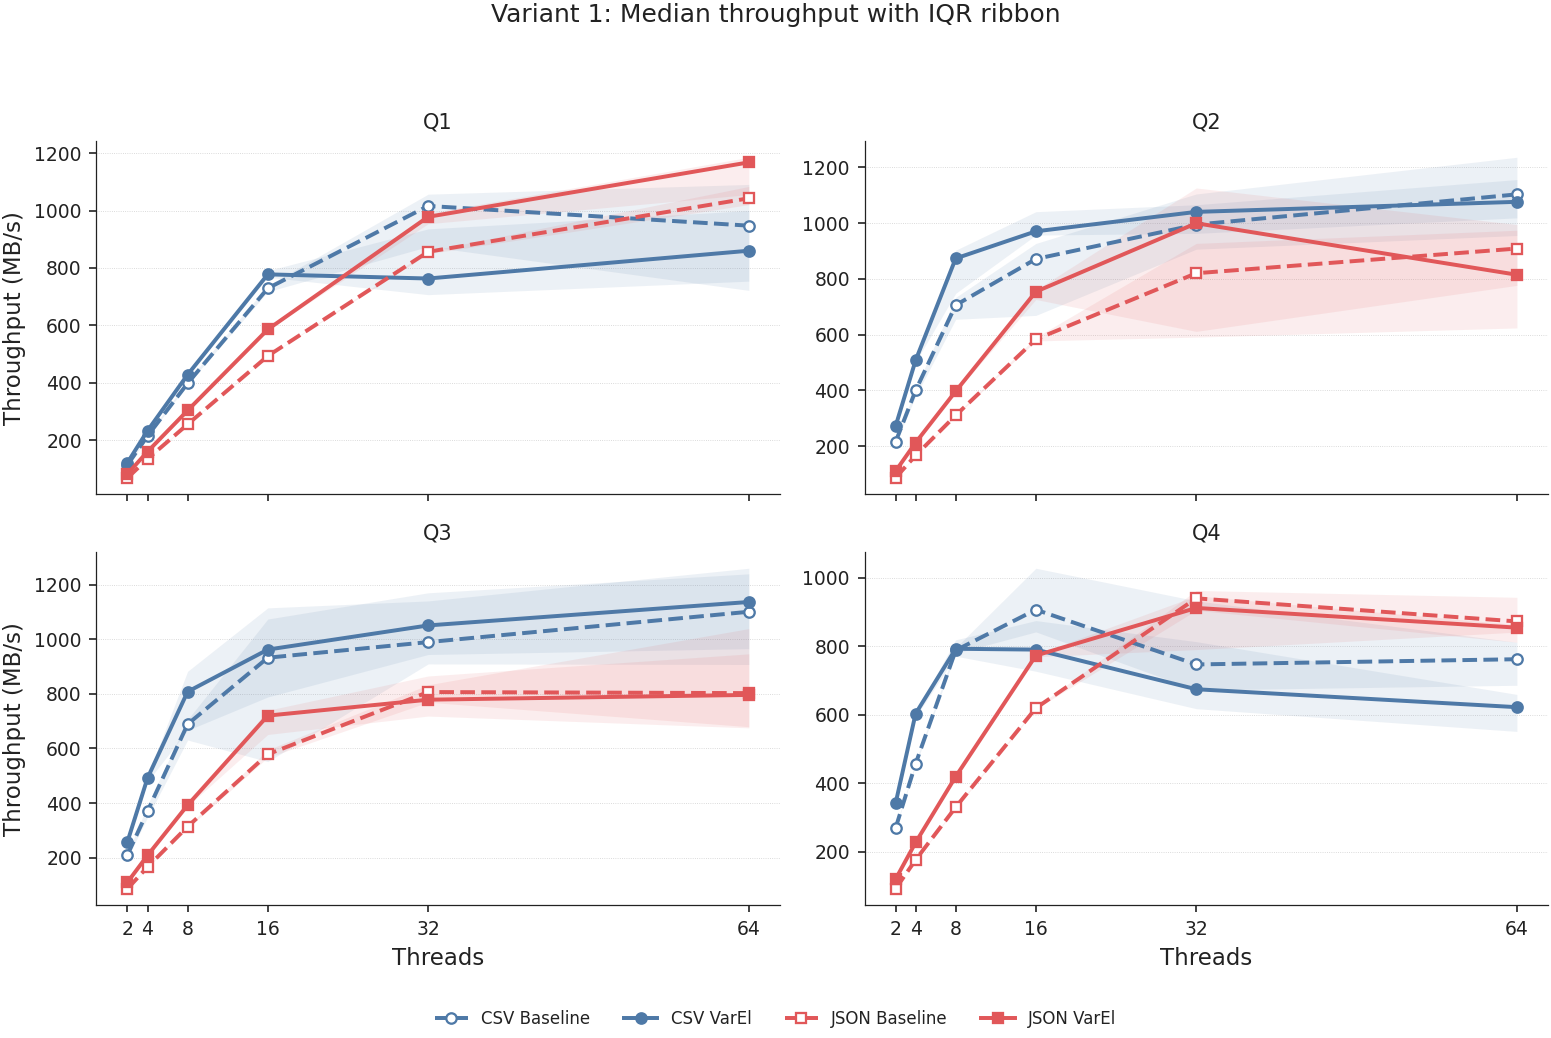

In [79]:

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

queries = sorted(df["query"].unique())
query_labels = {q: f"Q{i + 1}" for i, q in enumerate(queries)}
suites = SUITE_ORDER
thread_counts = sorted(df["threads"].unique())
suite_colors = {
    CSV_BASE_LABEL: "#4e79a7",
    CSV_NO_COPY_LABEL: "#4e79a7",
    JSON_BASE_LABEL: "#e15759",
    JSON_NO_COPY_LABEL: "#e15759",
}
suite_markers = {
    CSV_BASE_LABEL: "o",
    CSV_NO_COPY_LABEL: "o",
    JSON_BASE_LABEL: "s",
    JSON_NO_COPY_LABEL: "s",
}
suite_linestyles = {
    CSV_BASE_LABEL: "--",
    CSV_NO_COPY_LABEL: "-",
    JSON_BASE_LABEL: "--",
    JSON_NO_COPY_LABEL: "-",
}
suite_marker_faces = {
    CSV_BASE_LABEL: "white",
    CSV_NO_COPY_LABEL: "#4e79a7",
    JSON_BASE_LABEL: "white",
    JSON_NO_COPY_LABEL: "#e15759",
}

thesis_rc = {
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica", "Liberation Sans"],
    "font.size": 10,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "#222222",
    "axes.labelcolor": "#222222",
    "axes.titlecolor": "#222222",
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "axes.labelsize": 11,
    "axes.titlesize": 10,
    "axes.linewidth": 0.6,
    "axes.edgecolor": "#222222",
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "legend.frameon": False,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
}

def style_axis(ax):
    ax.grid(True, axis="y", linestyle=":", linewidth=0.4, alpha=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Variant 1: median throughput with IQR ribbons in the same plot
stats = (
    df.groupby(["query", "suite", "threads"])["throughput_MBs"]
    .agg(q1=lambda s: s.quantile(0.25), median="median", q3=lambda s: s.quantile(0.75))
    .reset_index()
)

with mpl.rc_context(thesis_rc):
    fig, axes = plt.subplots(2, 2, figsize=(10.6, 6.8), sharex=True, squeeze=False)

    for idx, q in enumerate(queries):
        row, col = divmod(idx, 2)
        ax = axes[row][col]
        for suite in suites:
            subset = (
                stats[(stats["query"] == q) & (stats["suite"] == suite)]
                .set_index("threads")
                .reindex(thread_counts)
            )
            x = np.array(thread_counts)
            median = subset["median"].to_numpy(dtype=float)
            q1 = subset["q1"].to_numpy(dtype=float)
            q3 = subset["q3"].to_numpy(dtype=float)
            ax.fill_between(x, q1, q3, color=suite_colors[suite], alpha=0.10, linewidth=0)
            ax.plot(
                x, median,
                marker=suite_markers[suite], markersize=5.0,
                linewidth=1.9, linestyle=suite_linestyles[suite],
                color=suite_colors[suite],
                markerfacecolor=suite_marker_faces[suite],
                markeredgecolor=suite_colors[suite], markeredgewidth=1.1,
                label=suite,
            )
        ax.set_title(query_labels[q])
        ax.set_xticks(thread_counts)
        style_axis(ax)
        if row == 1:
            ax.set_xlabel("Threads")
        if col == 0:
            ax.set_ylabel("Throughput (MB/s)")

    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.01))
    fig.suptitle("Variant 1: Median throughput with IQR ribbon", y=1.01)
    fig.tight_layout(rect=(0, 0.04, 1, 0.97))
    plt.show()


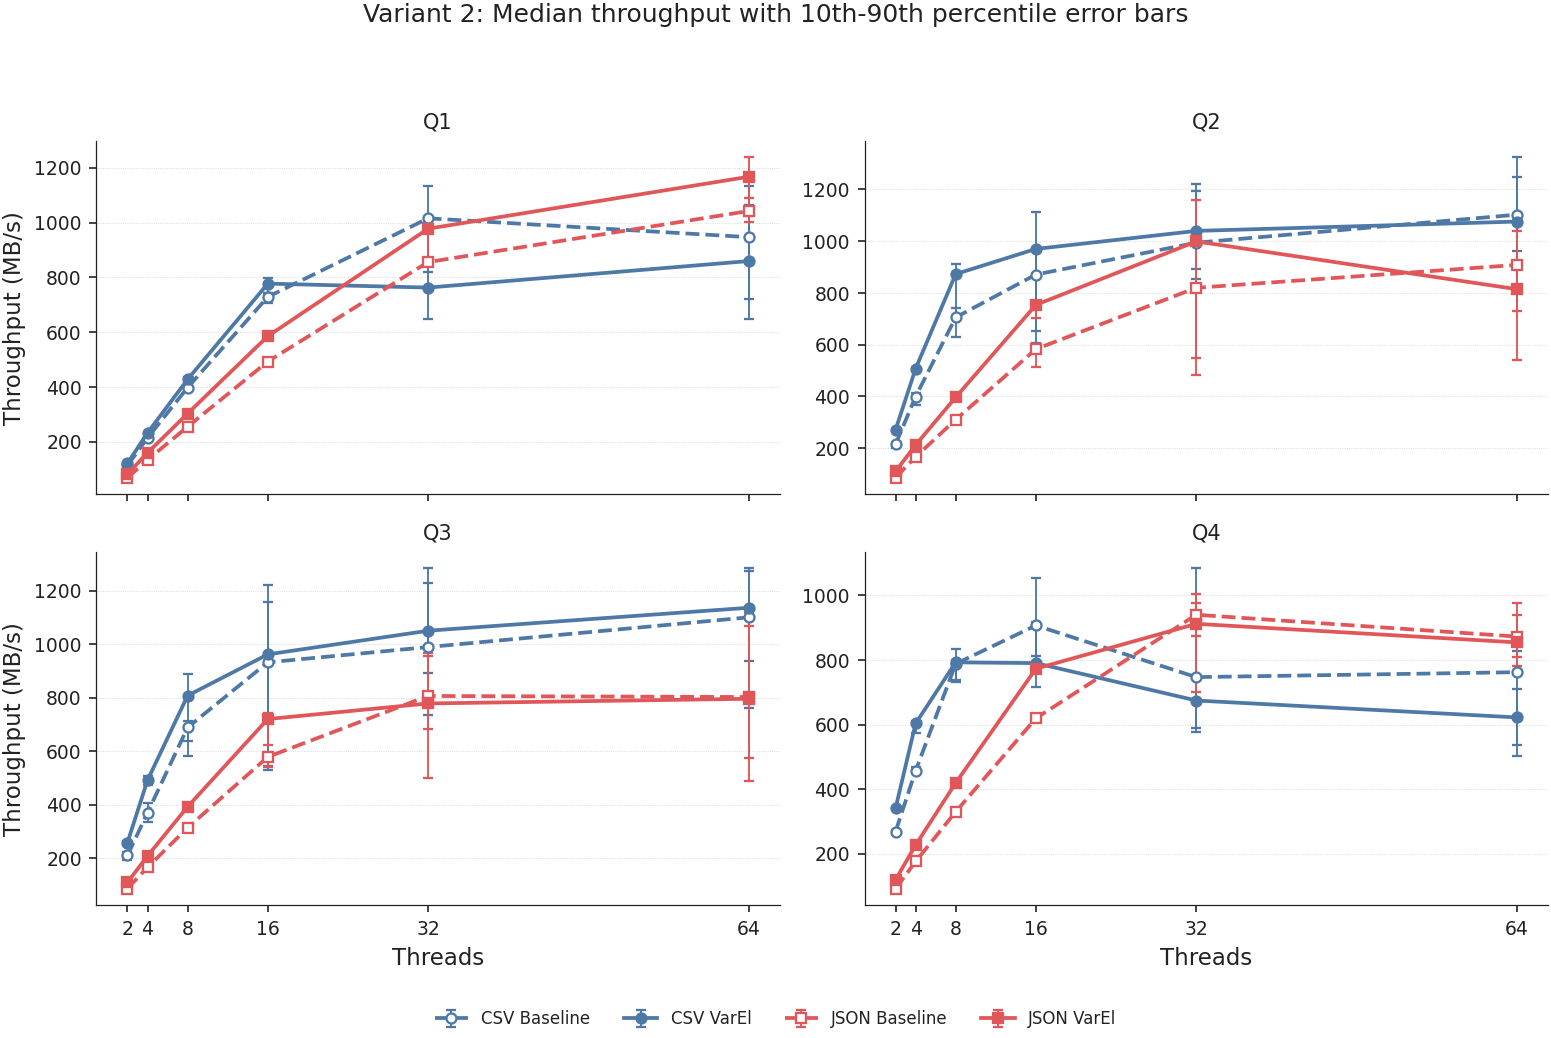

In [80]:

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

queries = sorted(df["query"].unique())
query_labels = {q: f"Q{i + 1}" for i, q in enumerate(queries)}
suites = SUITE_ORDER
thread_counts = sorted(df["threads"].unique())
suite_colors = {
    CSV_BASE_LABEL: "#4e79a7",
    CSV_NO_COPY_LABEL: "#4e79a7",
    JSON_BASE_LABEL: "#e15759",
    JSON_NO_COPY_LABEL: "#e15759",
}
suite_markers = {
    CSV_BASE_LABEL: "o",
    CSV_NO_COPY_LABEL: "o",
    JSON_BASE_LABEL: "s",
    JSON_NO_COPY_LABEL: "s",
}
suite_linestyles = {
    CSV_BASE_LABEL: "--",
    CSV_NO_COPY_LABEL: "-",
    JSON_BASE_LABEL: "--",
    JSON_NO_COPY_LABEL: "-",
}
suite_marker_faces = {
    CSV_BASE_LABEL: "white",
    CSV_NO_COPY_LABEL: "#4e79a7",
    JSON_BASE_LABEL: "white",
    JSON_NO_COPY_LABEL: "#e15759",
}

thesis_rc = {
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica", "Liberation Sans"],
    "font.size": 10,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "#222222",
    "axes.labelcolor": "#222222",
    "axes.titlecolor": "#222222",
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "axes.labelsize": 11,
    "axes.titlesize": 10,
    "axes.linewidth": 0.6,
    "axes.edgecolor": "#222222",
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "legend.frameon": False,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
}

def style_axis(ax):
    ax.grid(True, axis="y", linestyle=":", linewidth=0.4, alpha=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Variant 2: median throughput with vertical error bars (10th-90th percentile)
stats = (
    df.groupby(["query", "suite", "threads"])["throughput_MBs"]
    .agg(p10=lambda s: s.quantile(0.10), median="median", p90=lambda s: s.quantile(0.90))
    .reset_index()
)

with mpl.rc_context(thesis_rc):
    fig, axes = plt.subplots(2, 2, figsize=(10.6, 6.8), sharex=True, squeeze=False)

    for idx, q in enumerate(queries):
        row, col = divmod(idx, 2)
        ax = axes[row][col]
        for suite in suites:
            subset = (
                stats[(stats["query"] == q) & (stats["suite"] == suite)]
                .set_index("threads")
                .reindex(thread_counts)
            )
            x = np.array(thread_counts)
            median = subset["median"].to_numpy(dtype=float)
            p10 = subset["p10"].to_numpy(dtype=float)
            p90 = subset["p90"].to_numpy(dtype=float)
            yerr = np.vstack([median - p10, p90 - median])
            ax.errorbar(
                x, median, yerr=yerr,
                fmt=suite_markers[suite], markersize=4.8,
                linewidth=1.8, linestyle=suite_linestyles[suite],
                color=suite_colors[suite],
                markerfacecolor=suite_marker_faces[suite],
                markeredgecolor=suite_colors[suite], markeredgewidth=1.1,
                elinewidth=0.9, capsize=2.5, capthick=0.9,
                label=suite,
            )
        ax.set_title(query_labels[q])
        ax.set_xticks(thread_counts)
        style_axis(ax)
        if row == 1:
            ax.set_xlabel("Threads")
        if col == 0:
            ax.set_ylabel("Throughput (MB/s)")

    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.01))
    fig.suptitle("Variant 2: Median throughput with 10th-90th percentile error bars", y=1.01)
    fig.tight_layout(rect=(0, 0.04, 1, 0.97))
    plt.show()


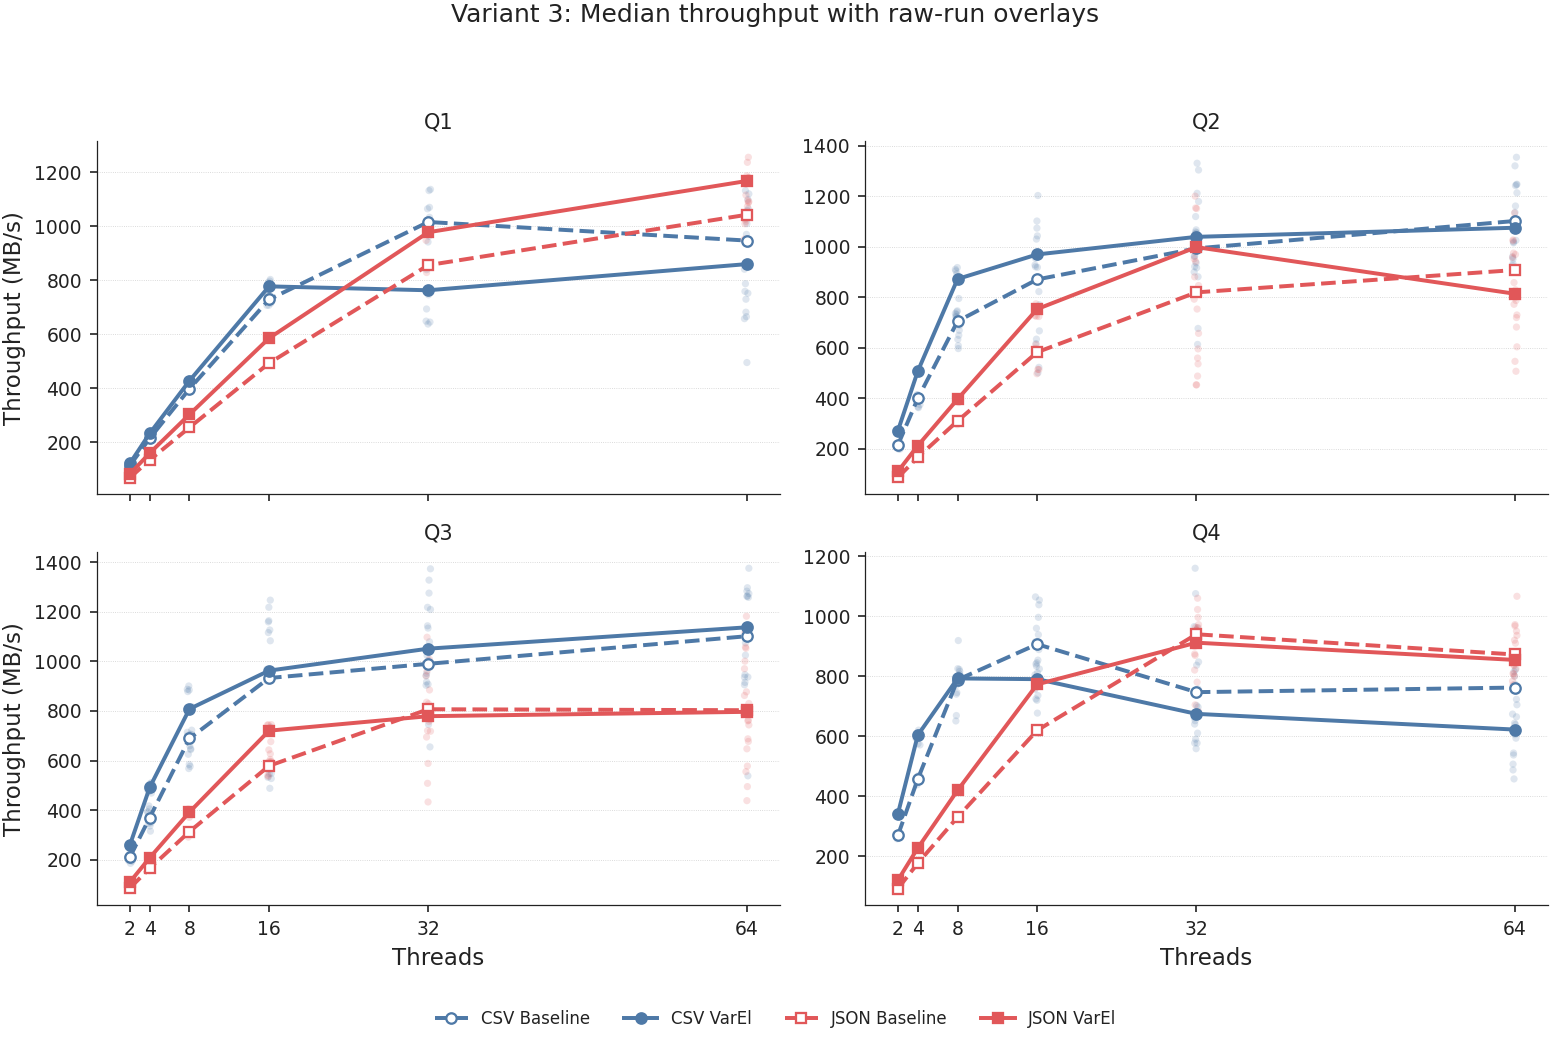

In [81]:

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

queries = sorted(df["query"].unique())
query_labels = {q: f"Q{i + 1}" for i, q in enumerate(queries)}
suites = SUITE_ORDER
thread_counts = sorted(df["threads"].unique())
suite_colors = {
    CSV_BASE_LABEL: "#4e79a7",
    CSV_NO_COPY_LABEL: "#4e79a7",
    JSON_BASE_LABEL: "#e15759",
    JSON_NO_COPY_LABEL: "#e15759",
}
suite_markers = {
    CSV_BASE_LABEL: "o",
    CSV_NO_COPY_LABEL: "o",
    JSON_BASE_LABEL: "s",
    JSON_NO_COPY_LABEL: "s",
}
suite_linestyles = {
    CSV_BASE_LABEL: "--",
    CSV_NO_COPY_LABEL: "-",
    JSON_BASE_LABEL: "--",
    JSON_NO_COPY_LABEL: "-",
}
suite_marker_faces = {
    CSV_BASE_LABEL: "white",
    CSV_NO_COPY_LABEL: "#4e79a7",
    JSON_BASE_LABEL: "white",
    JSON_NO_COPY_LABEL: "#e15759",
}

thesis_rc = {
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica", "Liberation Sans"],
    "font.size": 10,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "#222222",
    "axes.labelcolor": "#222222",
    "axes.titlecolor": "#222222",
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "axes.labelsize": 11,
    "axes.titlesize": 10,
    "axes.linewidth": 0.6,
    "axes.edgecolor": "#222222",
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "legend.frameon": False,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
}

def style_axis(ax):
    ax.grid(True, axis="y", linestyle=":", linewidth=0.4, alpha=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Variant 3: median throughput with faint raw-run points in the background
medians = (
    df.groupby(["query", "suite", "threads"])["throughput_MBs"]
    .median()
    .reset_index(name="median")
)

with mpl.rc_context(thesis_rc):
    fig, axes = plt.subplots(2, 2, figsize=(10.6, 6.8), sharex=True, squeeze=False)

    for idx, q in enumerate(queries):
        row, col = divmod(idx, 2)
        ax = axes[row][col]
        for suite in suites:
            raw = df[(df["query"] == q) & (df["suite"] == suite)]
            for t in thread_counts:
                runs = raw[raw["threads"] == t]["throughput_MBs"].to_numpy(dtype=float)
                if len(runs) == 0:
                    continue
                jitter = np.linspace(-0.22, 0.22, len(runs)) if len(runs) > 1 else np.array([0.0])
                ax.scatter(
                    np.full(len(runs), t, dtype=float) + jitter,
                    runs,
                    s=12,
                    color=suite_colors[suite],
                    alpha=0.18,
                    edgecolors="none",
                )
            subset = (
                medians[(medians["query"] == q) & (medians["suite"] == suite)]
                .set_index("threads")
                .reindex(thread_counts)
            )
            ax.plot(
                thread_counts, subset["median"].to_numpy(dtype=float),
                marker=suite_markers[suite], markersize=5.0,
                linewidth=1.9, linestyle=suite_linestyles[suite],
                color=suite_colors[suite],
                markerfacecolor=suite_marker_faces[suite],
                markeredgecolor=suite_colors[suite], markeredgewidth=1.1,
                label=suite,
            )
        ax.set_title(query_labels[q])
        ax.set_xticks(thread_counts)
        style_axis(ax)
        if row == 1:
            ax.set_xlabel("Threads")
        if col == 0:
            ax.set_ylabel("Throughput (MB/s)")

    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.01))
    fig.suptitle("Variant 3: Median throughput with raw-run overlays", y=1.01)
    fig.tight_layout(rect=(0, 0.04, 1, 0.97))
    plt.show()


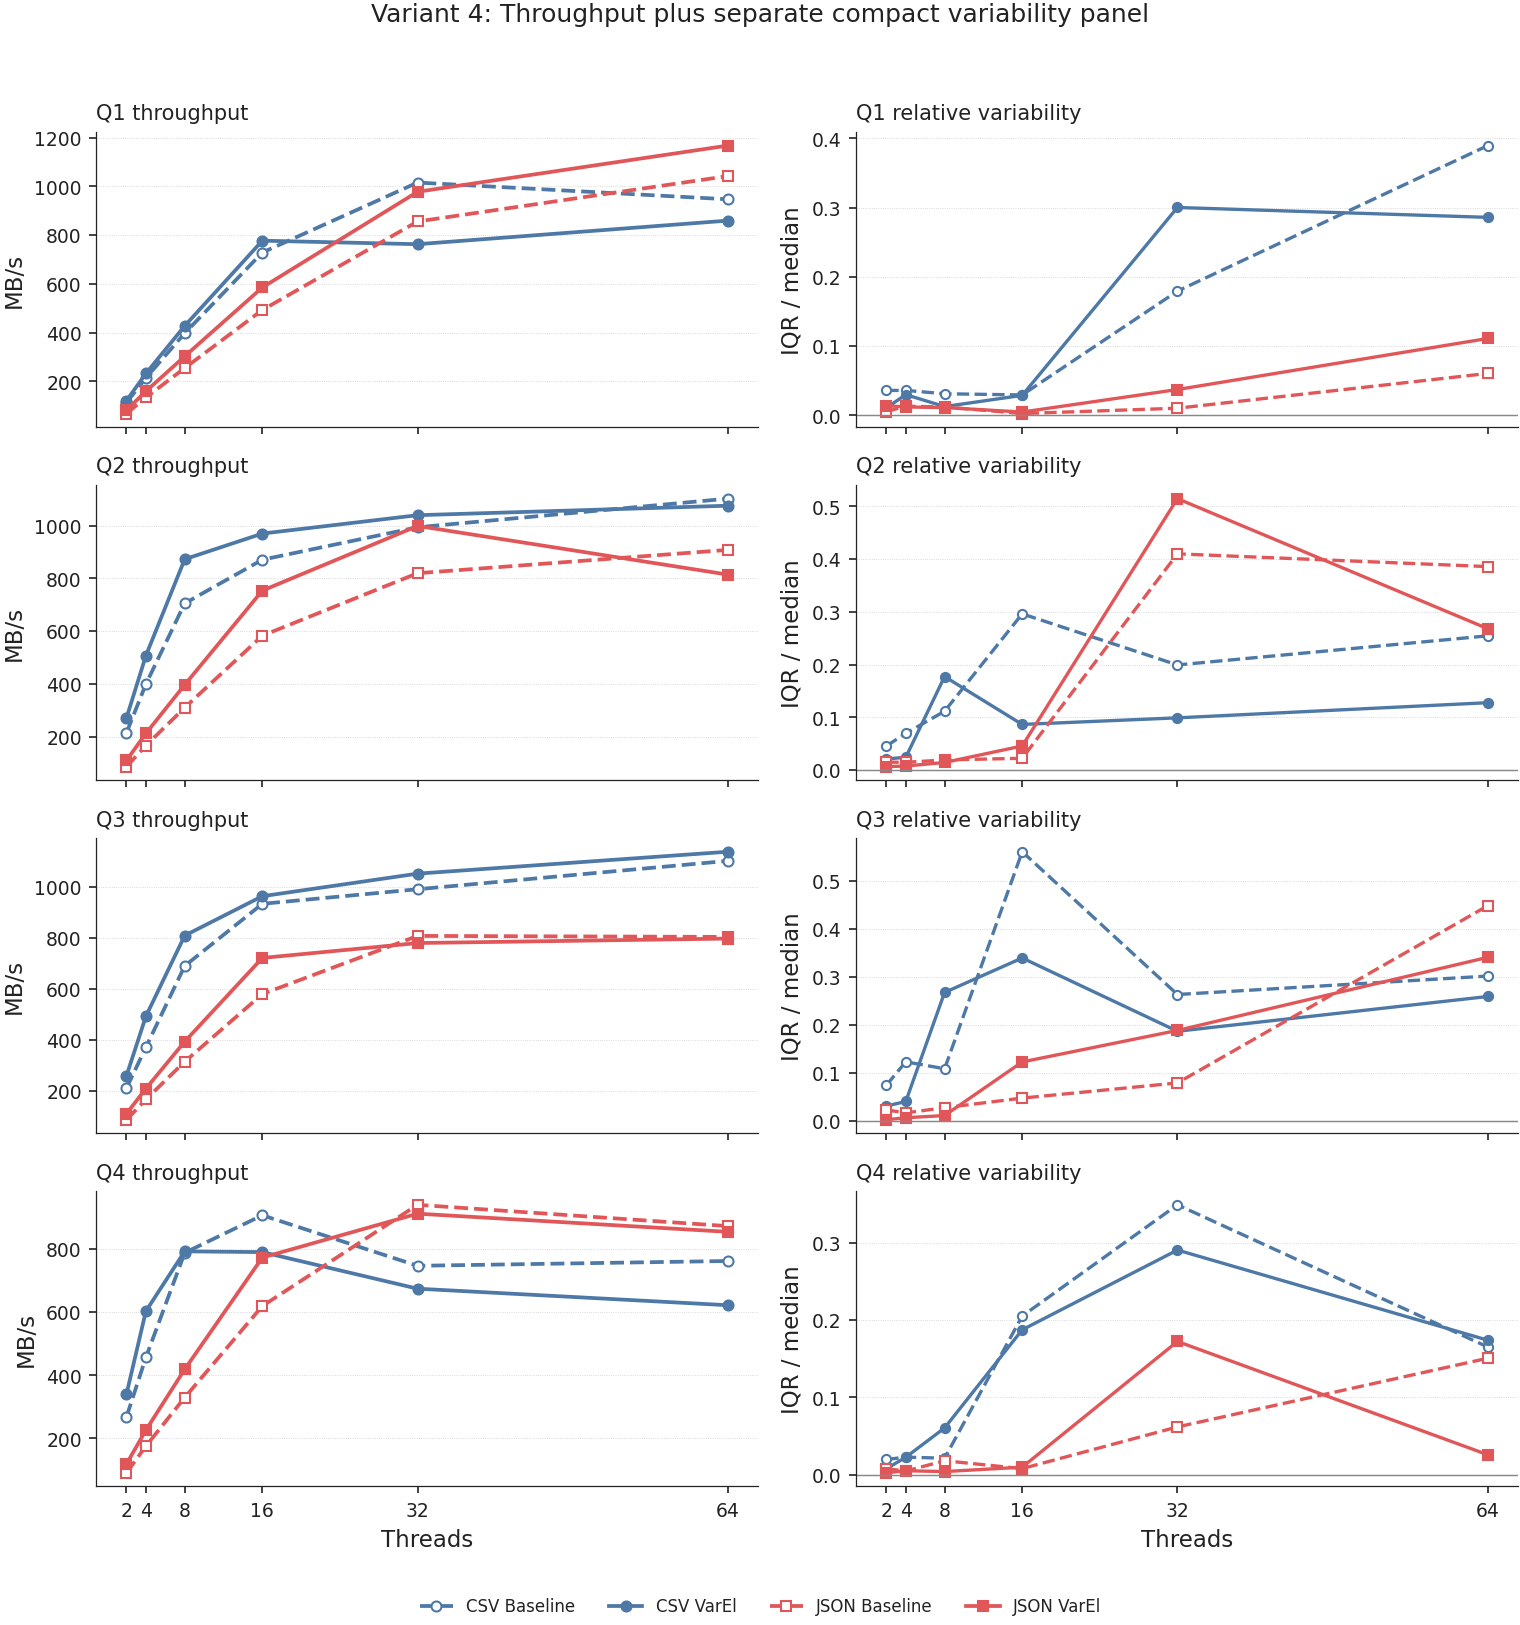

In [82]:

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

queries = sorted(df["query"].unique())
query_labels = {q: f"Q{i + 1}" for i, q in enumerate(queries)}
suites = SUITE_ORDER
thread_counts = sorted(df["threads"].unique())
suite_colors = {
    CSV_BASE_LABEL: "#4e79a7",
    CSV_NO_COPY_LABEL: "#4e79a7",
    JSON_BASE_LABEL: "#e15759",
    JSON_NO_COPY_LABEL: "#e15759",
}
suite_markers = {
    CSV_BASE_LABEL: "o",
    CSV_NO_COPY_LABEL: "o",
    JSON_BASE_LABEL: "s",
    JSON_NO_COPY_LABEL: "s",
}
suite_linestyles = {
    CSV_BASE_LABEL: "--",
    CSV_NO_COPY_LABEL: "-",
    JSON_BASE_LABEL: "--",
    JSON_NO_COPY_LABEL: "-",
}
suite_marker_faces = {
    CSV_BASE_LABEL: "white",
    CSV_NO_COPY_LABEL: "#4e79a7",
    JSON_BASE_LABEL: "white",
    JSON_NO_COPY_LABEL: "#e15759",
}

thesis_rc = {
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica", "Liberation Sans"],
    "font.size": 10,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "#222222",
    "axes.labelcolor": "#222222",
    "axes.titlecolor": "#222222",
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "axes.labelsize": 11,
    "axes.titlesize": 10,
    "axes.linewidth": 0.6,
    "axes.edgecolor": "#222222",
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "legend.frameon": False,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
}

def style_axis(ax):
    ax.grid(True, axis="y", linestyle=":", linewidth=0.4, alpha=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Variant 4: median throughput plus relative variability (IQR / median) in a compact paired layout
stats = (
    df.groupby(["query", "suite", "threads"])["throughput_MBs"]
    .agg(q1=lambda s: s.quantile(0.25), median="median", q3=lambda s: s.quantile(0.75))
    .reset_index()
)
stats["iqr_over_median"] = (stats["q3"] - stats["q1"]) / stats["median"]

with mpl.rc_context(thesis_rc):
    fig, axes = plt.subplots(4, 2, figsize=(10.4, 10.8), sharex='col', squeeze=False)

    for idx, q in enumerate(queries):
        ax_tp = axes[idx][0]
        ax_var = axes[idx][1]
        for suite in suites:
            subset = (
                stats[(stats["query"] == q) & (stats["suite"] == suite)]
                .set_index("threads")
                .reindex(thread_counts)
            )
            ax_tp.plot(
                thread_counts, subset["median"].to_numpy(dtype=float),
                marker=suite_markers[suite], markersize=4.8,
                linewidth=1.8, linestyle=suite_linestyles[suite],
                color=suite_colors[suite],
                markerfacecolor=suite_marker_faces[suite],
                markeredgecolor=suite_colors[suite], markeredgewidth=1.0,
                label=suite,
            )
            ax_var.plot(
                thread_counts, subset["iqr_over_median"].to_numpy(dtype=float),
                marker=suite_markers[suite], markersize=4.4,
                linewidth=1.6, linestyle=suite_linestyles[suite],
                color=suite_colors[suite],
                markerfacecolor=suite_marker_faces[suite],
                markeredgecolor=suite_colors[suite], markeredgewidth=1.0,
            )
        ax_tp.set_title(f"{query_labels[q]} throughput", loc="left")
        ax_var.set_title(f"{query_labels[q]} relative variability", loc="left")
        ax_tp.set_xticks(thread_counts)
        ax_var.set_xticks(thread_counts)
        style_axis(ax_tp)
        style_axis(ax_var)
        ax_var.axhline(0, color="#888888", linewidth=0.7)
        if idx == len(queries) - 1:
            ax_tp.set_xlabel("Threads")
            ax_var.set_xlabel("Threads")
        ax_tp.set_ylabel("MB/s")
        ax_var.set_ylabel("IQR / median")

    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.005))
    fig.suptitle("Variant 4: Throughput plus separate compact variability panel", y=1.0)
    fig.tight_layout(rect=(0, 0.03, 1, 0.98))
    plt.show()


wrote plots/varsized_copy_exec_time_q1.pdf


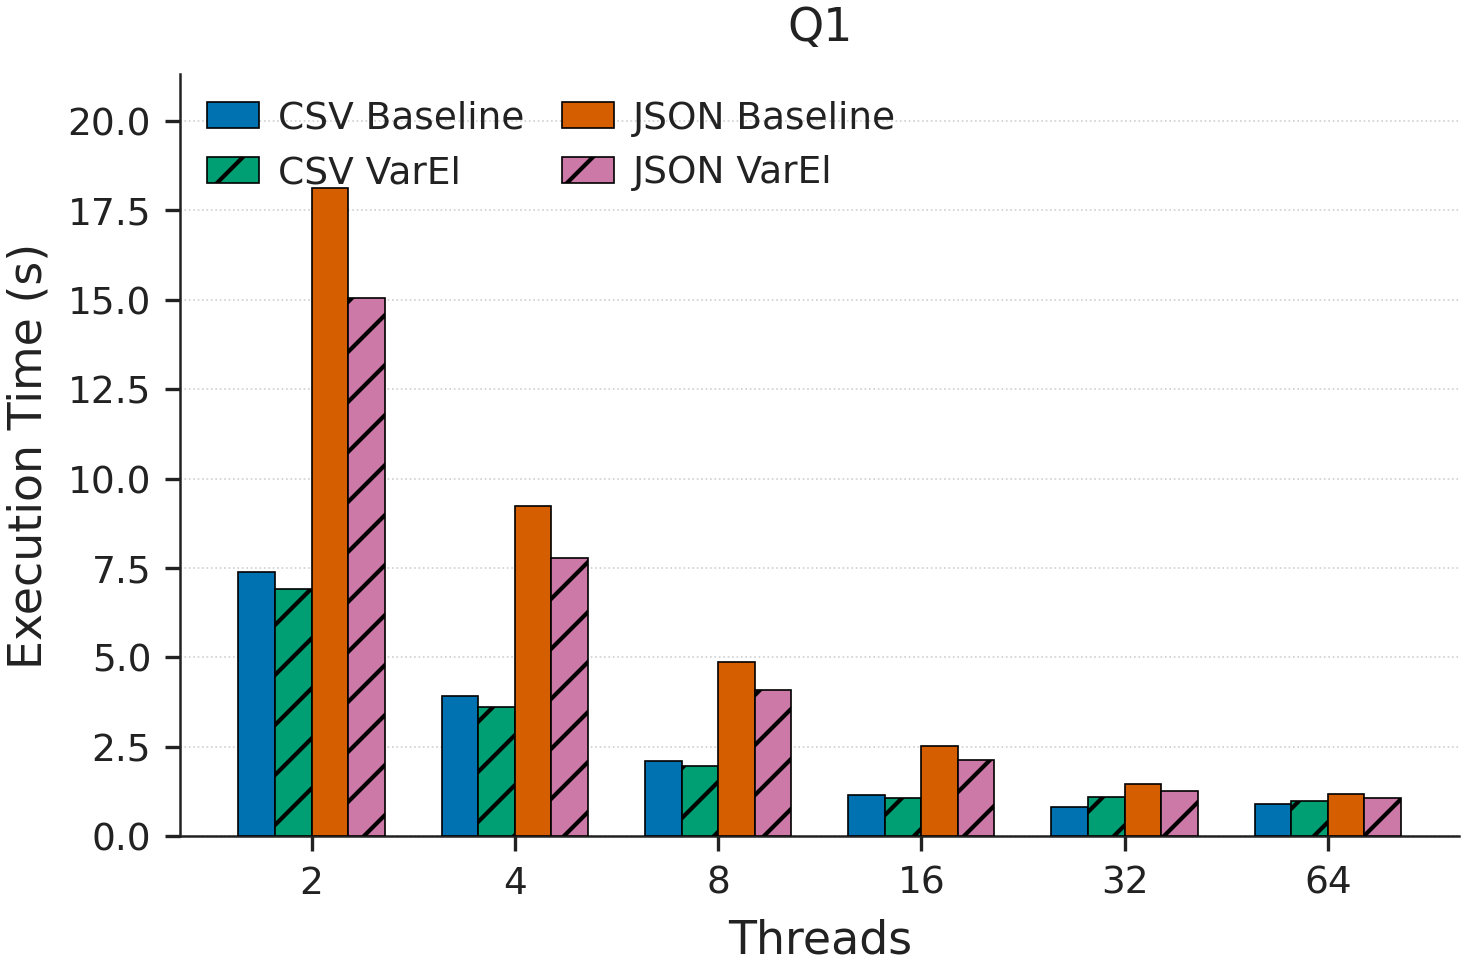

wrote plots/varsized_copy_exec_time_q2.pdf


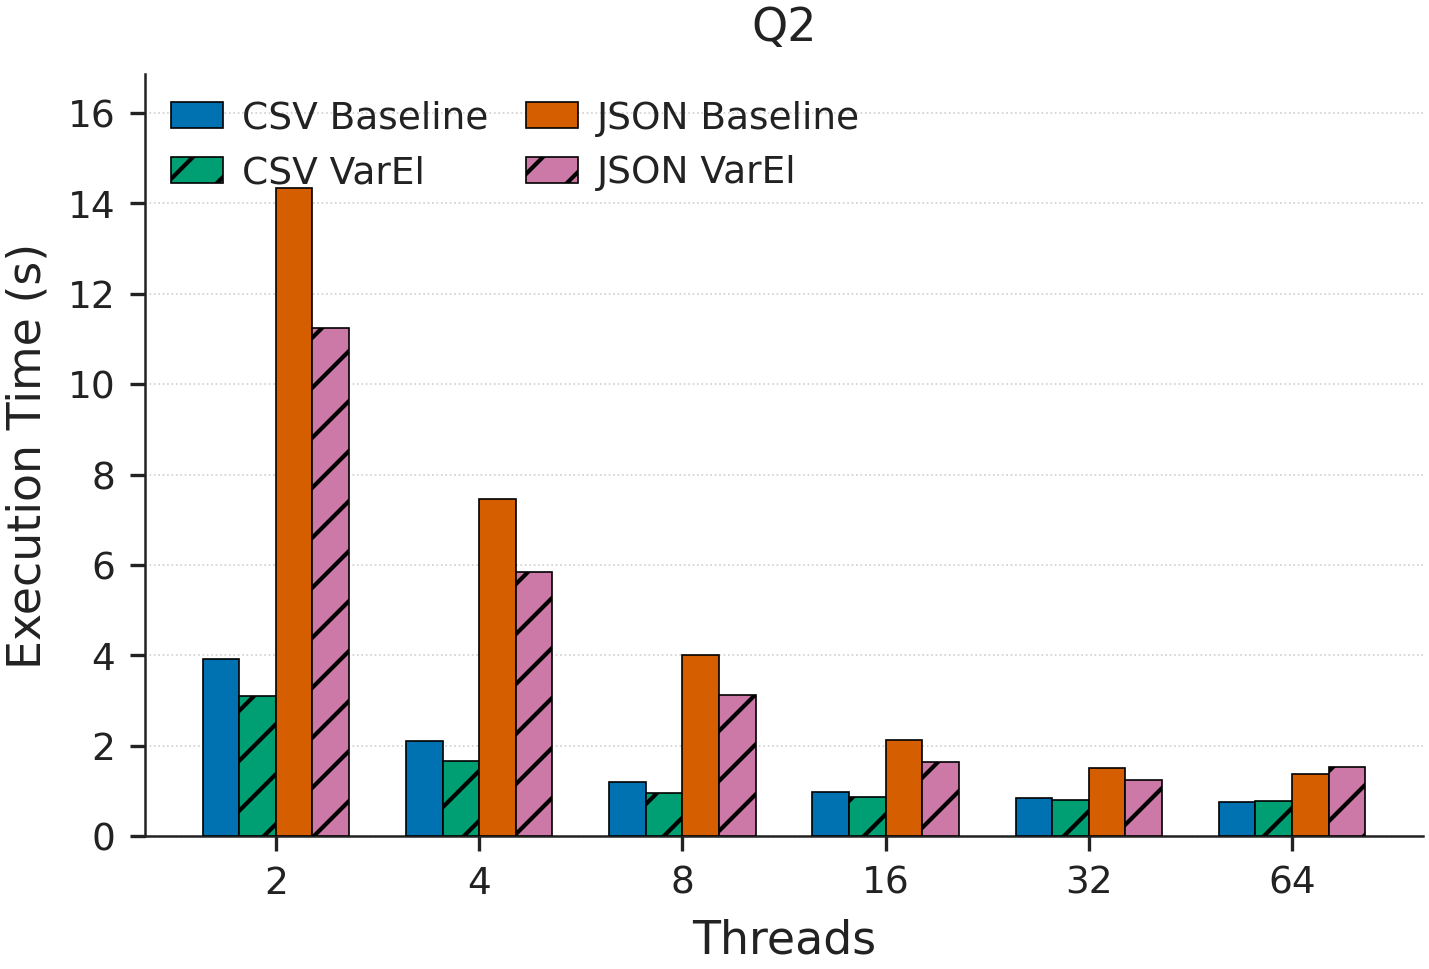

wrote plots/varsized_copy_exec_time_q3.pdf


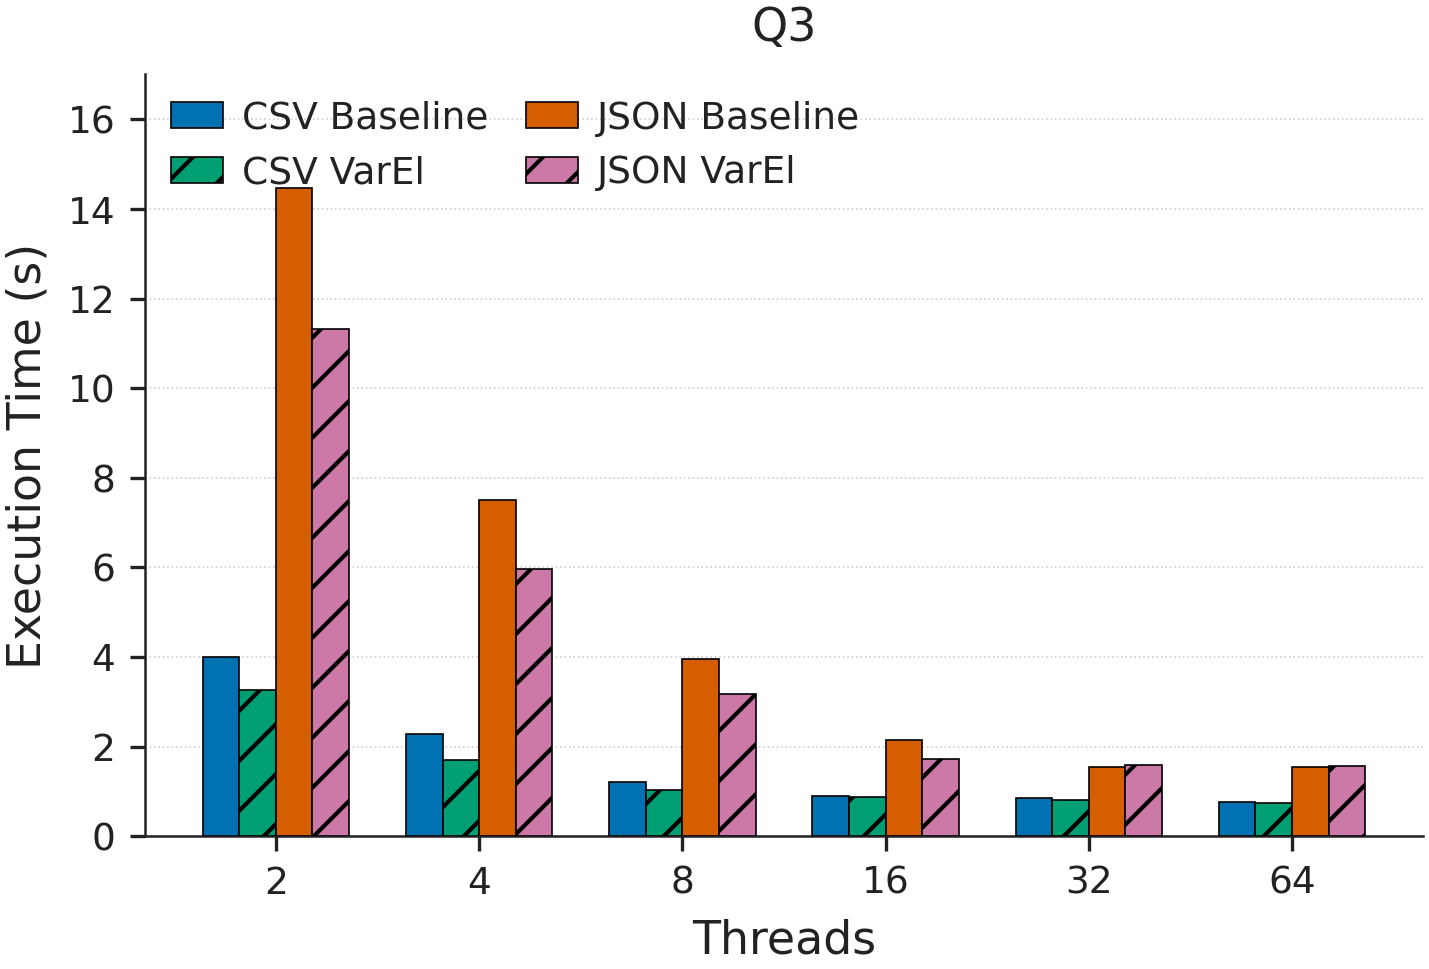

wrote plots/varsized_copy_exec_time_q4.pdf


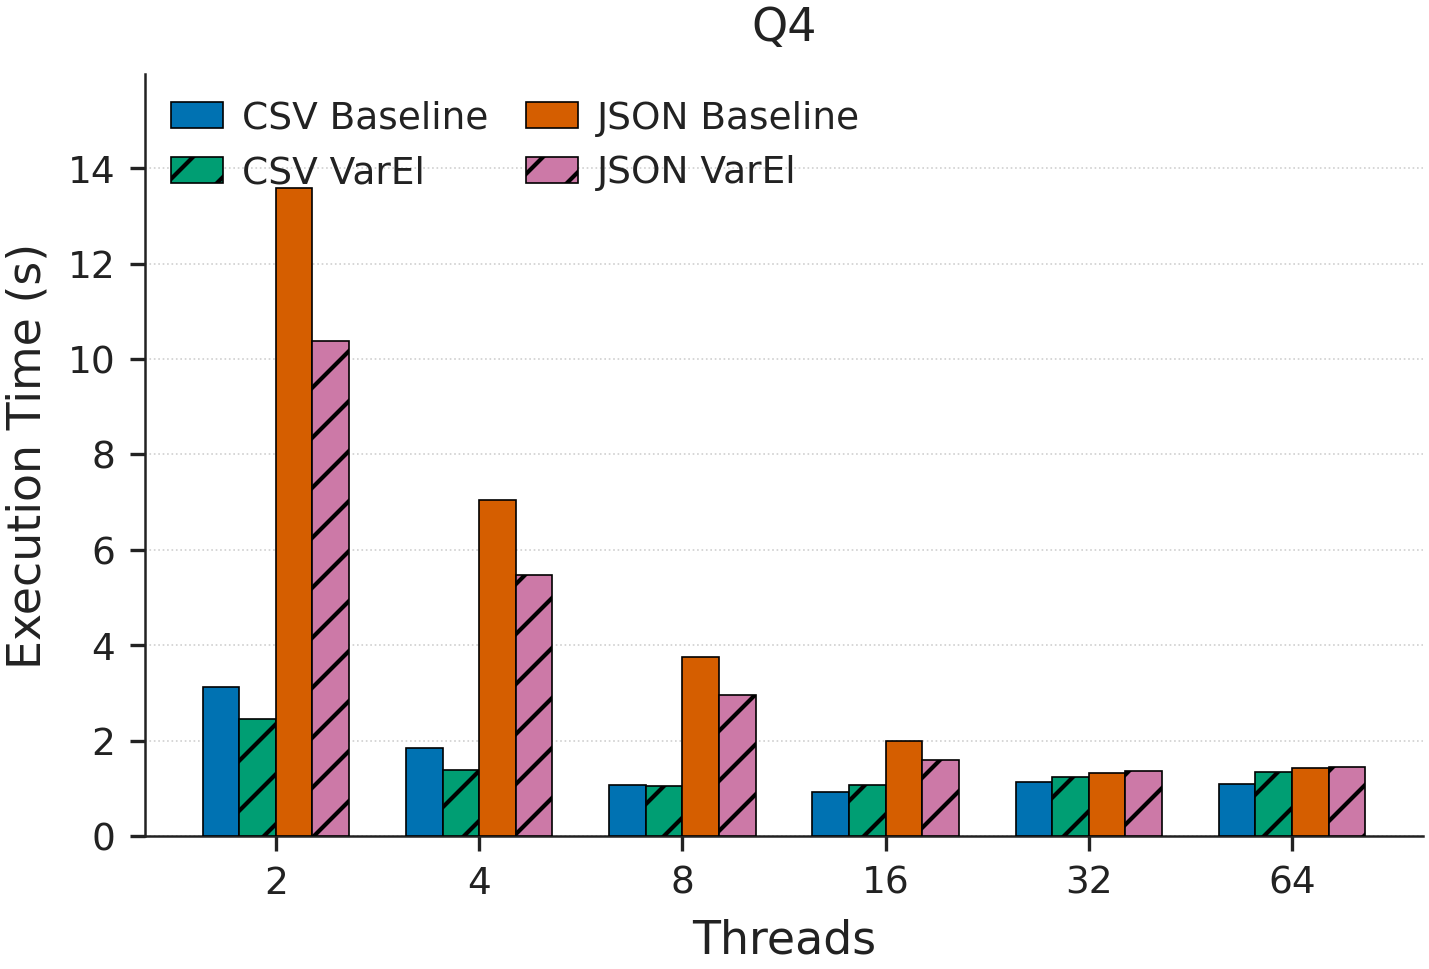

In [83]:
# Grouped bar chart: execution time per thread count, one standalone plot per query
import os
import re
import numpy as np
import matplotlib as mpl
import matplotlib.patheffects as pe

PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

thesis_rc = {
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica", "Liberation Sans"],
    "font.size": 10,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "#222222",
    "axes.labelcolor": "#222222",
    "axes.titlecolor": "#222222",
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "axes.linewidth": 0.6,
    "axes.edgecolor": "#222222",
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.frameon": False,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
}

queries = sorted(df["query"].unique())
query_labels = {q: f"Q{i + 1}" for i, q in enumerate(queries)}
suites = SUITE_ORDER
suite_colors = SUITE_COLORS
suite_hatch = SUITE_HATCH
thread_counts = sorted(df["threads"].unique())
n_suites = len(suites)
bar_width = 0.18
x = np.arange(len(thread_counts))

query_file_labels = {
    q: re.sub(r"[^a-z0-9]+", "_", query_labels[q].lower()).strip("_") for q in queries
}

with mpl.rc_context(thesis_rc):
    for q in queries:
        fig, ax = plt.subplots(figsize=(5.5, 3.3), dpi=300)

        for j, suite in enumerate(suites):
            s_data = df[(df["query"] == q) & (df["suite"] == suite)]
            vals = s_data.groupby("threads")["exec_time_s"].median().reindex(thread_counts)
            offset = (j - (n_suites - 1) / 2) * bar_width
            bars = ax.bar(
                x + offset,
                vals.values,
                bar_width,
                label=suite,
                color=suite_colors[suite],
                edgecolor="black",
                linewidth=0.4,
                hatch=suite_hatch[suite],
                zorder=3,
            )

        ax.set_xlabel("Threads")
        ax.set_ylabel("Execution Time (s)")
        ax.set_title(query_labels[q], pad=8)
        ax.set_xticks(x)
        ax.set_xticklabels(thread_counts)
        ax.set_ylim(0, ax.get_ylim()[1] * 1.12)
        ax.grid(True, axis="y", linestyle=":", linewidth=0.4, alpha=0.6, zorder=0)
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.legend(
            loc="upper left",
            ncol=2,
            columnspacing=1.0,
            handlelength=1.4,
            handletextpad=0.5,
            borderaxespad=0.3,
        )

        out = os.path.join(
            PLOTS_DIR,
            f"varsized_copy_exec_time_{query_file_labels[q]}.pdf",
        )
        fig.savefig(out)
        print(f"wrote {out}")
        plt.show()

wrote plots/varsized_copy_throughput_median.pdf


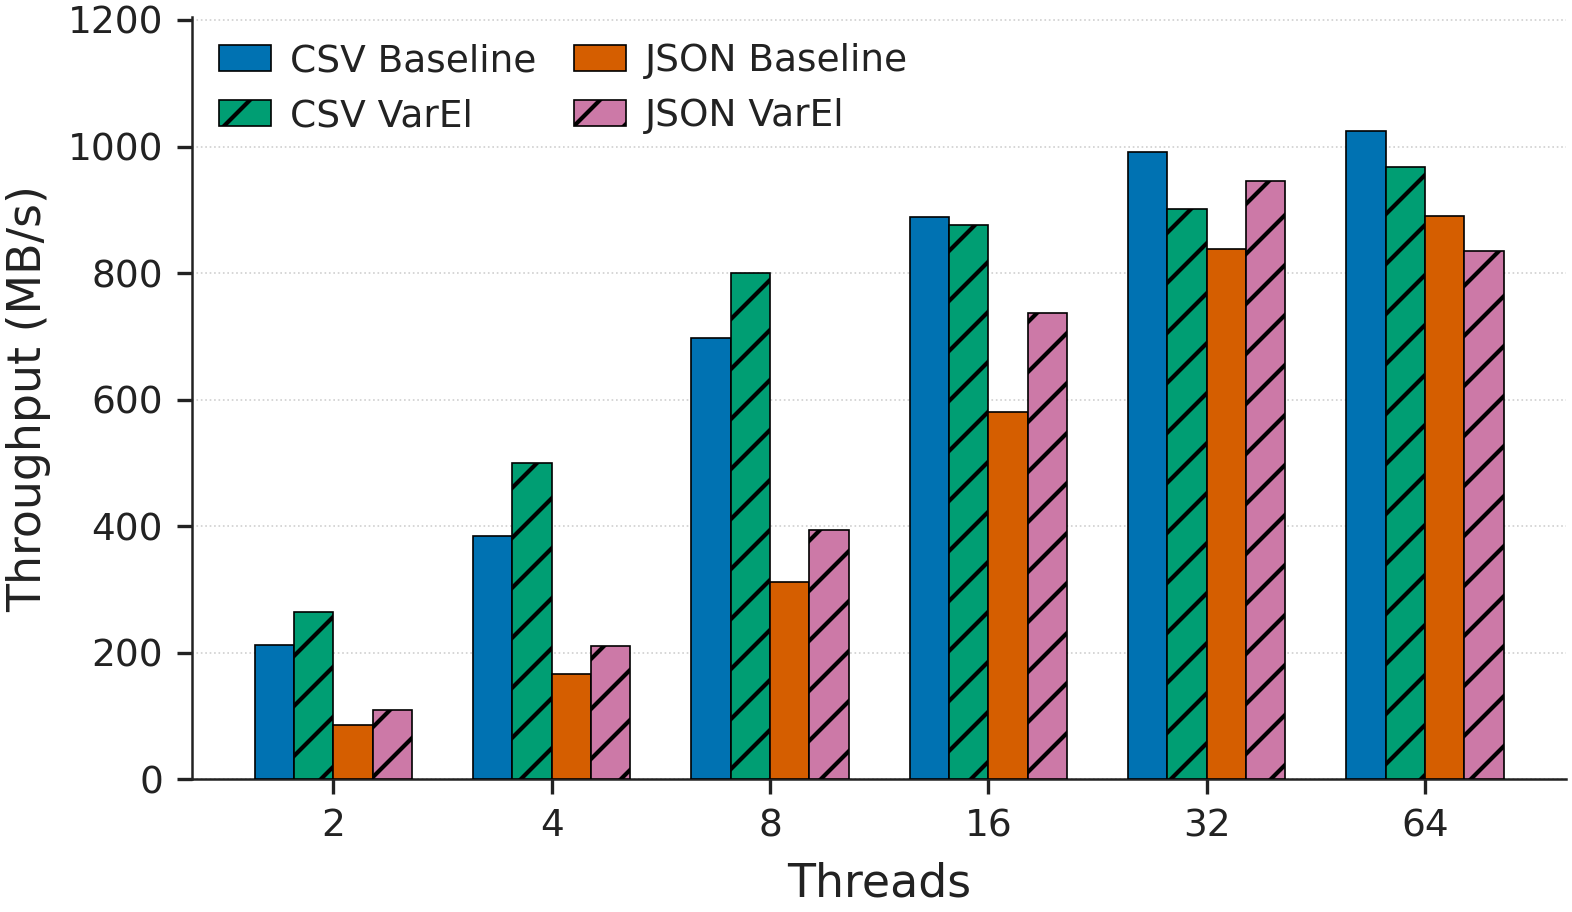

In [84]:
# Median throughput across all queries per suite & thread count
import os
import numpy as np
import matplotlib as mpl
import matplotlib.patheffects as pe

PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

thesis_rc = {
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica", "Liberation Sans"],
    "font.size": 10,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "#222222",
    "axes.labelcolor": "#222222",
    "axes.titlecolor": "#222222",
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "axes.linewidth": 0.6,
    "axes.edgecolor": "#222222",
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.frameon": False,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
}

suites = SUITE_ORDER
suite_colors = SUITE_COLORS
suite_hatch = SUITE_HATCH
thread_counts = sorted(df["threads"].unique())
n_suites = len(suites)
bar_width = 0.18
x = np.arange(len(thread_counts))

median_across = (
    df.groupby(["suite", "threads", "query"])["throughput_MBs"]
    .median()
    .groupby(level=["suite", "threads"])
    .median()
)

with mpl.rc_context(thesis_rc):
    fig, ax = plt.subplots(figsize=(5.5, 3.3), dpi=300)

    for j, suite in enumerate(suites):
        if suite not in median_across.index.get_level_values("suite"):
            continue
        vals = median_across.loc[suite].reindex(thread_counts)
        offset = (j - (n_suites - 1) / 2) * bar_width
        bars = ax.bar(
            x + offset,
            vals.values,
            bar_width,
            label=suite,
            color=suite_colors[suite],
            edgecolor="black",
            linewidth=0.4,
            hatch=suite_hatch[suite],
            zorder=3,
        )

    ax.set_xlabel("Threads")
    ax.set_ylabel("Throughput (MB/s)")
    ax.set_xticks(x)
    ax.set_xticklabels(thread_counts)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.12)
    ax.grid(True, axis="y", linestyle=":", linewidth=0.4, alpha=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(
        loc="upper left",
        ncol=2,
        columnspacing=1.0,
        handlelength=1.4,
        handletextpad=0.5,
        borderaxespad=0.3,
    )

    fig.tight_layout()
    out = os.path.join(PLOTS_DIR, "varsized_copy_throughput_median.pdf")
    fig.savefig(out)
    print(f"wrote {out}")
    plt.show()

wrote plots/varsized_copy_throughput_variance.pdf


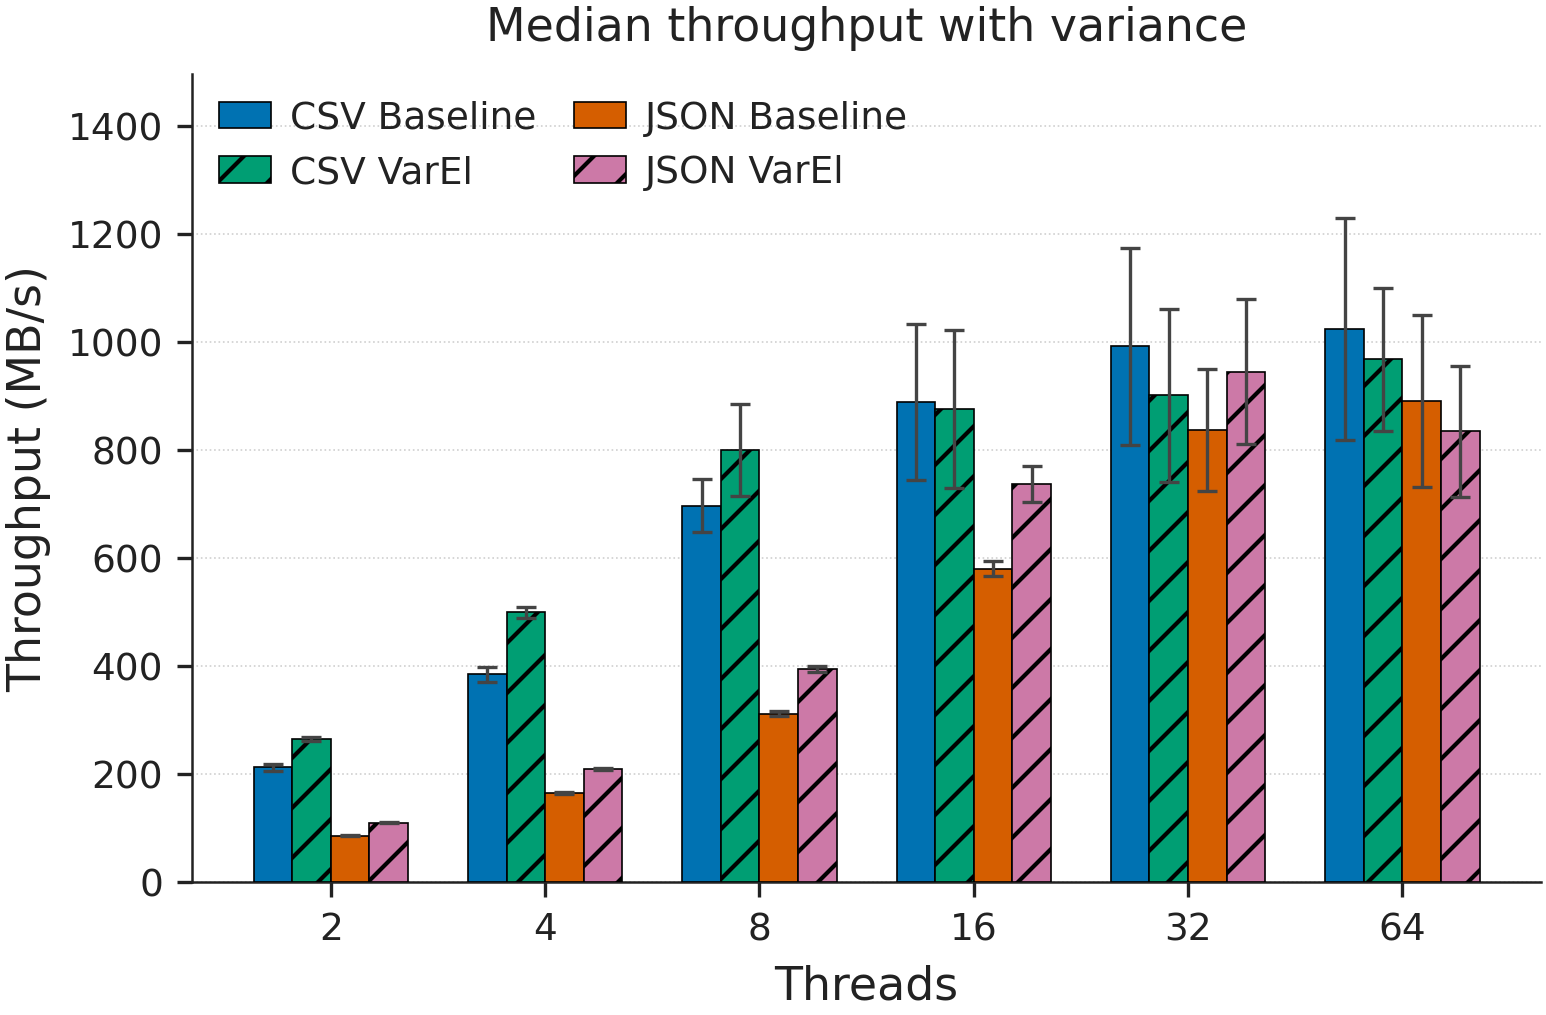

In [85]:
# Throughput variability across repeated executions per suite & thread count
import os
import numpy as np
import matplotlib as mpl
import matplotlib.patheffects as pe

PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

thesis_rc = {
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica", "Liberation Sans"],
    "font.size": 10,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "#222222",
    "axes.labelcolor": "#222222",
    "axes.titlecolor": "#222222",
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "axes.linewidth": 0.6,
    "axes.edgecolor": "#222222",
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.frameon": False,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
}

suites = SUITE_ORDER
suite_colors = SUITE_COLORS
suite_hatch = SUITE_HATCH
thread_counts = sorted(df["threads"].unique())
n_suites = len(suites)
bar_width = 0.18
x = np.arange(len(thread_counts))

per_query_stats = (
    df.groupby(["suite", "threads", "query"])["throughput_MBs"]
    .agg(center="median", spread=lambda s: s.std(ddof=1))
    .fillna(0.0)
)

variance_summary = (
    per_query_stats.groupby(level=["suite", "threads"])
    .agg(center=("center", "median"), spread=("spread", "median"))
)

with mpl.rc_context(thesis_rc):
    fig, ax = plt.subplots(figsize=(5.8, 3.5), dpi=300)

    for j, suite in enumerate(suites):
        if suite not in variance_summary.index.get_level_values("suite"):
            continue
        center = variance_summary.loc[suite]["center"].reindex(thread_counts)
        spread = variance_summary.loc[suite]["spread"].reindex(thread_counts).fillna(0.0)
        offset = (j - (n_suites - 1) / 2) * bar_width
        bars = ax.bar(
            x + offset,
            center.values,
            bar_width,
            label=suite,
            color=suite_colors[suite],
            edgecolor="black",
            linewidth=0.4,
            hatch=suite_hatch[suite],
            yerr=spread.values,
            error_kw={"elinewidth": 0.8, "ecolor": "#444444", "capsize": 2.5, "capthick": 0.8},
            zorder=3,
        )

    ax.set_xlabel("Threads")
    ax.set_ylabel("Throughput (MB/s)")
    ax.set_title("Median throughput with variance", pad=8)
    ax.set_xticks(x)
    ax.set_xticklabels(thread_counts)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.16)
    ax.grid(True, axis="y", linestyle=":", linewidth=0.4, alpha=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(
        loc="upper left",
        ncol=2,
        columnspacing=1.0,
        handlelength=1.4,
        handletextpad=0.5,
        borderaxespad=0.3,
    )

    out = os.path.join(PLOTS_DIR, "varsized_copy_throughput_variance.pdf")
    fig.savefig(out)
    print(f"wrote {out}")
    plt.show()

In [86]:
# Summary table: throughput (MB/s) all 4 suites
all_suites = [s for s in SUITE_ORDER if s in df["suite"].unique()]
pivot = df.pivot_table(index=["query", "threads"], columns="suite", values="throughput_MBs", aggfunc="median")
pivot = pivot[[s for s in all_suites if s in pivot.columns]]
if CSV_BASE_LABEL in pivot.columns and CSV_NO_COPY_LABEL in pivot.columns:
    pivot["CSV speedup"] = pivot[CSV_NO_COPY_LABEL] / pivot[CSV_BASE_LABEL]
if JSON_BASE_LABEL in pivot.columns and JSON_NO_COPY_LABEL in pivot.columns:
    pivot["JSON speedup"] = pivot[JSON_NO_COPY_LABEL] / pivot[JSON_BASE_LABEL]
pivot.round(2)

suite                                                       CSV Baseline  \
query                                              threads                 
SELECT * FROM PERSON                               2              113.67   
                                                   4              214.42   
                                                   8              397.98   
                                                   16             728.97   
                                                   32            1015.95   
                                                   64             947.20   
SELECT CREDIT_CARD FROM PERSON                     2              214.82   
                                                   4              399.45   
                                                   8              705.45   
                                                   16             871.02   
                                                   32             994.04   
                                                   64            1102.60   
SELECT EXTRA FROM PERSON                           2              209.91   
                                                   4              369.87   
                                                   8              688.86   
                                                   16             932.58   
                                                   32             989.75   
                                                   64            1101.01   
SELECT ID FROM PERSON WHERE CITY == "redmond" A... 2              268.63   
                                                   4              456.85   
                                                   8              788.16   
                                                   16             906.97   
                                                   32             746.93   
                                                   64             762.19   

suite                                                       CSV VarEl  \
query                                              threads              
SELECT * FROM PERSON                               2           121.40   
                                                   4           232.73   
                                                   8           427.98   
                                                   16          777.54   
                                                   32          763.06   
                                                   64          859.91   
SELECT CREDIT_CARD FROM PERSON                     2           271.32   
                                                   4           507.48   
                                                   8           872.87   
                                                   16          970.13   
                                                   32         1039.77   
                                                   64         1075.82   
SELECT EXTRA FROM PERSON                           2           258.27   
                                                   4           491.46   
                                                   8           807.93   
                                                   16          962.38   
                                                   32         1050.89   
                                                   64         1136.85   
SELECT ID FROM PERSON WHERE CITY == "redmond" A... 2           340.69   
                                                   4           603.33   
                                                   8           792.71   
                                                   16          790.33   
                                                   32          674.49   
                                                   64          622.08   

suite                                                       JSON Baseline  \
query                                          

In [87]:
# LaTeX per-query throughput table in thesis format.
# Requires in thesis preamble: \usepackage{booktabs,multirow}

required_suites = SUITE_ORDER
missing = [suite for suite in required_suites if suite not in df["suite"].unique()]
if missing:
    raise ValueError(f"Missing suites for LaTeX export: {missing}")

tbl = (
    df.pivot_table(
        index=["query", "threads"],
        columns="suite",
        values="throughput_MBs",
        aggfunc="median",
    )[required_suites]
)

tbl["CSV speedup"] = tbl[CSV_NO_COPY_LABEL] / tbl[CSV_BASE_LABEL]
tbl["JSON speedup"] = tbl[JSON_NO_COPY_LABEL] / tbl[JSON_BASE_LABEL]

queries_sorted = sorted(tbl.index.get_level_values("query").unique())
query_labels = {q: f"Q{i + 1}" for i, q in enumerate(queries_sorted)}

def fmt_tp(v):
    return "--" if pd.isna(v) else f"{v:.0f}"

def fmt_sp(v):
    return "--" if pd.isna(v) else f"{v:.2f}"

lines = []
lines.append(r"\begin{table}[ht]")
lines.append(r"  \centering")
lines.append(r"  \label{tab:varsized-copy-per-query}")
lines.append(r"  \begin{tabular}{llrrrrrr}")
lines.append(r"    \toprule")
lines.append(r"    \multirow{2}{*}{Query} & \multirow{2}{*}{Threads} & \multicolumn{3}{c}{CSV (MB/s)} & \multicolumn{3}{c}{JSON (MB/s)} \\")
lines.append(r"    \cmidrule(lr){3-5} \cmidrule(lr){6-8}")
lines.append(r"     &  & base & no-copy & speedup & base & no-copy & speedup \\")
lines.append(r"    \midrule")

for qi, q in enumerate(queries_sorted):
    sub = tbl.loc[q].sort_index()
    q_cell = rf"\multirow{{{len(sub)}}}{{*}}{{{query_labels[q]}}}"
    for ri, (threads, row) in enumerate(sub.iterrows()):
        cells = [
            q_cell if ri == 0 else "",
            str(int(threads)),
            fmt_tp(row[CSV_BASE_LABEL]),
            fmt_tp(row[CSV_NO_COPY_LABEL]),
            fmt_sp(row["CSV speedup"]),
            fmt_tp(row[JSON_BASE_LABEL]),
            fmt_tp(row[JSON_NO_COPY_LABEL]),
            fmt_sp(row["JSON speedup"]),
        ]
        lines.append("    " + " & ".join(cells) + r" \\")
    if qi < len(queries_sorted) - 1:
        lines.append(r"    \midrule")

lines.append(r"    \bottomrule")
lines.append(r"  \end{tabular}")
lines.append(r"\end{table}")

latex_str = "\n".join(lines)
print(latex_str)

with open("results/per_query_table.tex", "w") as f:
    f.write(latex_str + "\n")
print("\n-> saved to results/per_query_table.tex")

\begin{table}[ht]
  \centering
  \label{tab:varsized-copy-per-query}
  \begin{tabular}{llrrrrrr}
    \toprule
    \multirow{2}{*}{Query} & \multirow{2}{*}{Threads} & \multicolumn{3}{c}{CSV (MB/s)} & \multicolumn{3}{c}{JSON (MB/s)} \\
    \cmidrule(lr){3-5} \cmidrule(lr){6-8}
     &  & base & no-copy & speedup & base & no-copy & speedup \\
    \midrule
    \multirow{6}{*}{Q1} & 2 & 114 & 121 & 1.07 & 68 & 82 & 1.20 \\
     & 4 & 214 & 233 & 1.09 & 134 & 160 & 1.19 \\
     & 8 & 398 & 428 & 1.08 & 255 & 303 & 1.19 \\
     & 16 & 729 & 778 & 1.07 & 493 & 586 & 1.19 \\
     & 32 & 1016 & 763 & 0.75 & 856 & 978 & 1.14 \\
     & 64 & 947 & 860 & 0.91 & 1043 & 1168 & 1.12 \\
    \midrule
    \multirow{6}{*}{Q2} & 2 & 215 & 271 & 1.26 & 87 & 110 & 1.28 \\
     & 4 & 399 & 507 & 1.27 & 166 & 212 & 1.28 \\
     & 8 & 705 & 873 & 1.24 & 310 & 397 & 1.28 \\
     & 16 & 871 & 970 & 1.11 & 583 & 754 & 1.29 \\
     & 32 & 994 & 1040 & 1.05 & 820 & 999 & 1.22 \\
     & 64 & 1103 & 1076 & 0.98 & 908 & 

wrote plots/varsized_copy_runs_q1.pdf


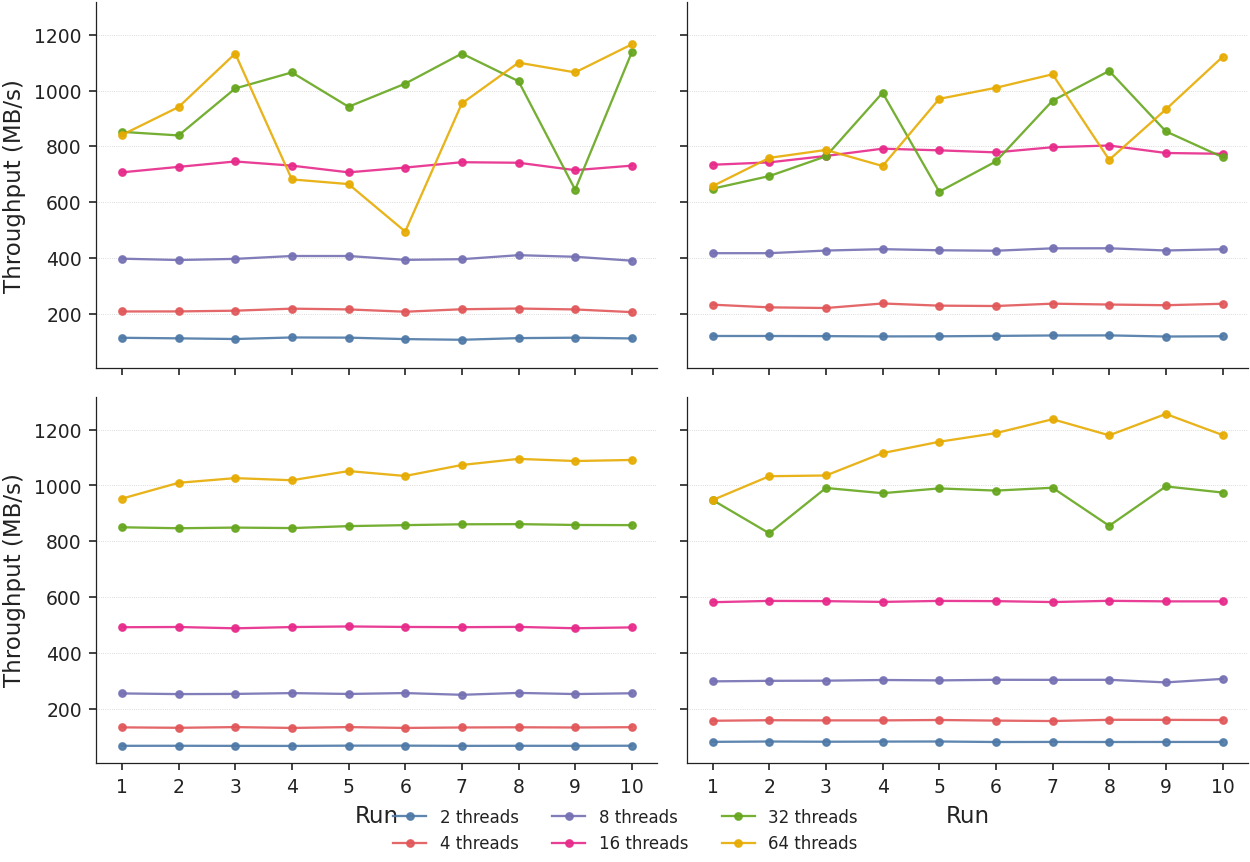

wrote plots/varsized_copy_runs_q2.pdf


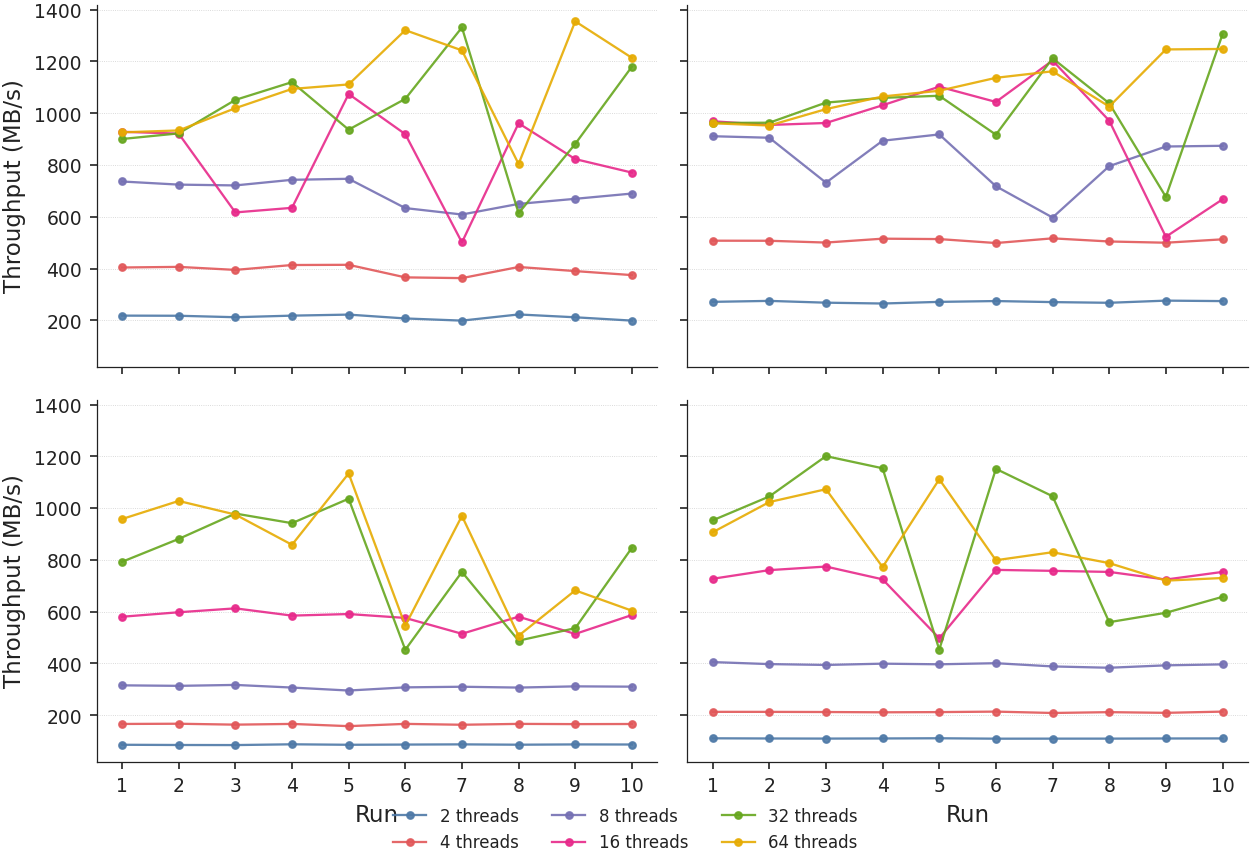

wrote plots/varsized_copy_runs_q3.pdf


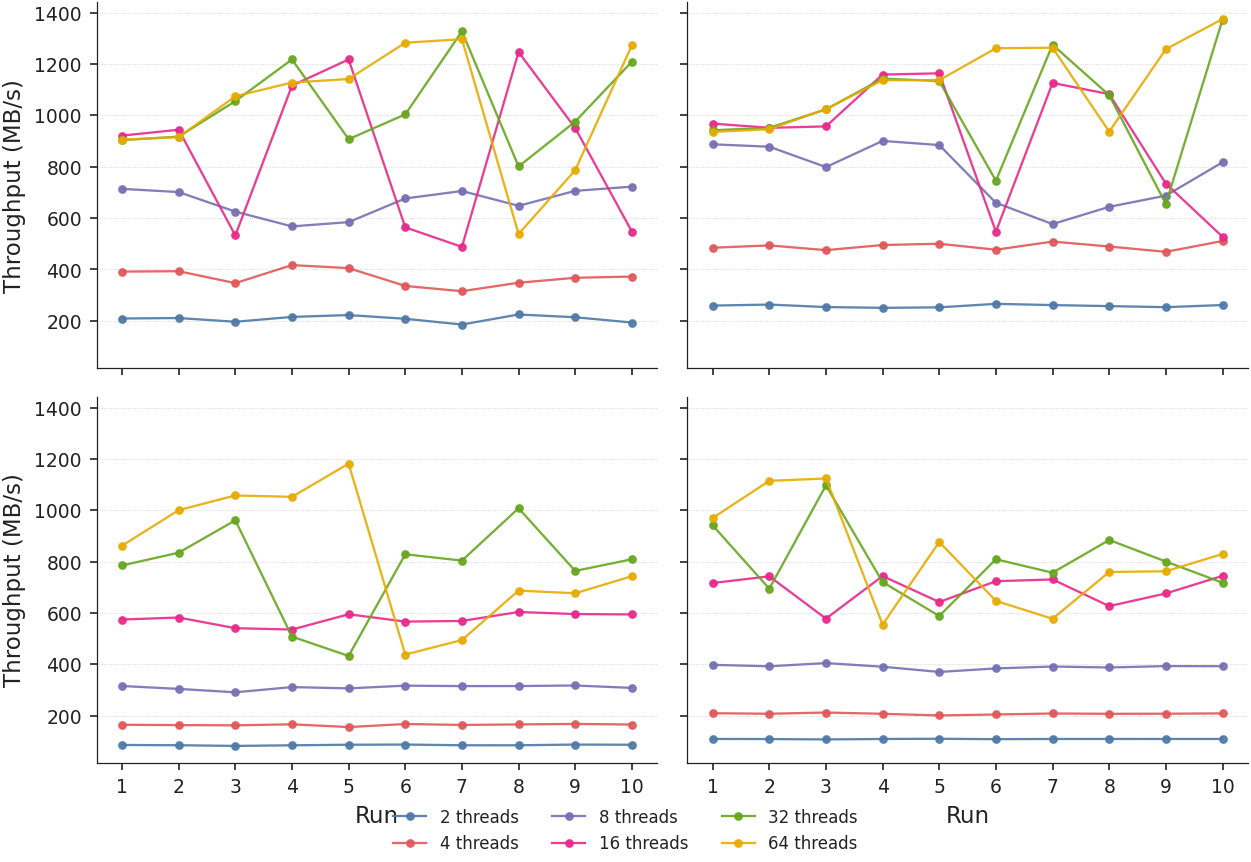

wrote plots/varsized_copy_runs_q4.pdf


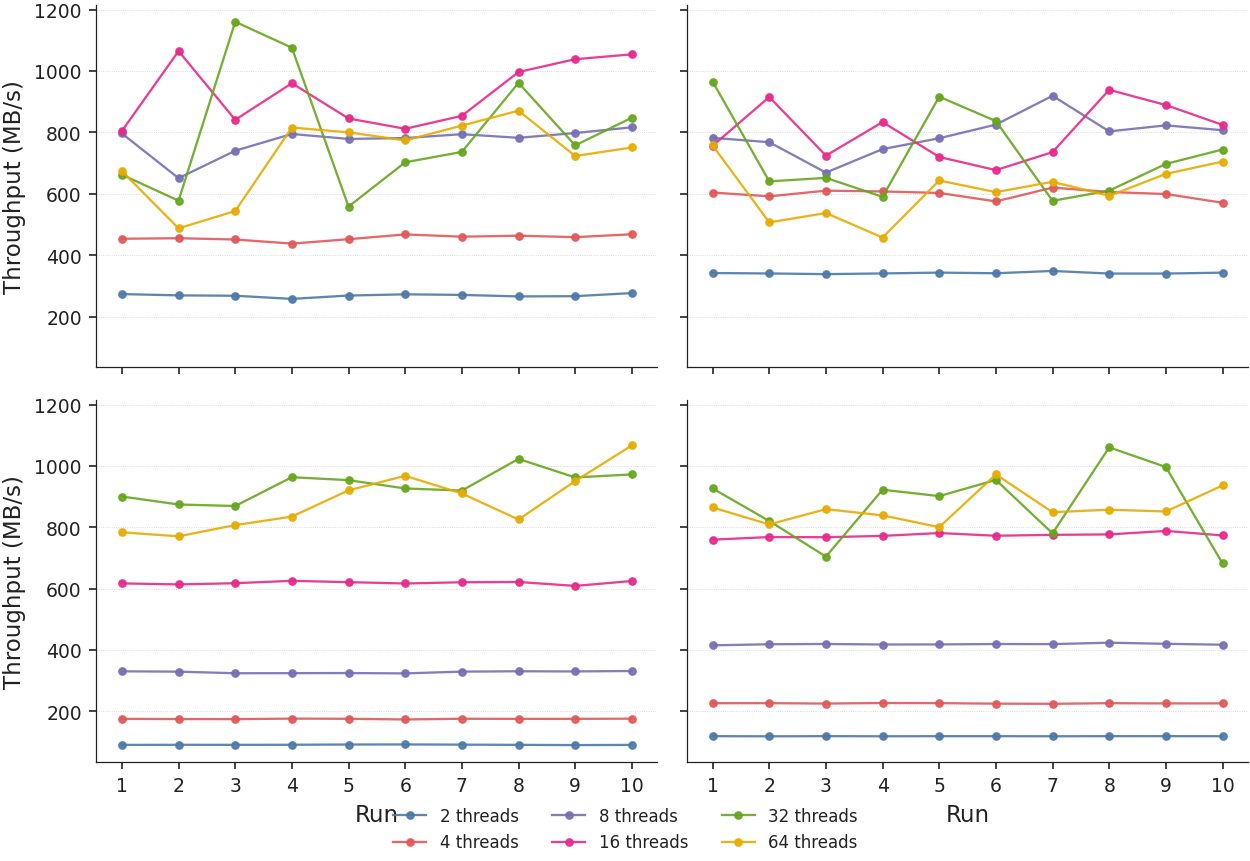

In [88]:
# Diagnostic plot: throughput over repeated runs, split by query and thread count
import os
import re
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

thesis_rc = {
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica", "Liberation Sans"],
    "font.size": 10,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "#222222",
    "axes.labelcolor": "#222222",
    "axes.titlecolor": "#222222",
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "axes.labelsize": 11,
    "axes.titlesize": 10,
    "axes.linewidth": 0.6,
    "axes.edgecolor": "#222222",
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "legend.frameon": False,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
}

df_runs = df.copy()
df_runs["run"] = df_runs.groupby(["suite", "query", "threads"]).cumcount() + 1

queries = sorted(df_runs["query"].unique())
query_labels = {q: f"Q{i + 1}" for i, q in enumerate(queries)}
query_file_labels = {
    q: re.sub(r"[^a-z0-9]+", "_", query_labels[q].lower()).strip("_") for q in queries
}
suites = SUITE_ORDER
thread_counts = sorted(df_runs["threads"].unique())
thread_colors = {
    2: "#4e79a7",
    4: "#e15759",
    8: "#7570b3",
    16: "#e7298a",
    32: "#66a61e",
    64: "#e6ab02",
}

with mpl.rc_context(thesis_rc):
    for q in queries:
        fig, axes = plt.subplots(2, 2, figsize=(8.6, 5.8), sharex=True, sharey=True, squeeze=False)

        for idx, suite in enumerate(suites):
            row, col = divmod(idx, 2)
            ax = axes[row][col]
            subset = df_runs[(df_runs["query"] == q) & (df_runs["suite"] == suite)]

            for threads in thread_counts:
                t_data = subset[subset["threads"] == threads].sort_values("run")
                if t_data.empty:
                    continue
                ax.plot(
                    t_data["run"],
                    t_data["throughput_MBs"],
                    marker="o",
                    markersize=3.2,
                    linewidth=1.1,
                    color=thread_colors.get(threads, "#444444"),
                    alpha=0.9,
                    label=f"{threads} threads",
                )

            ax.set_xticks(range(1, 11))
            ax.grid(True, axis="y", linestyle=":", linewidth=0.4, alpha=0.6, zorder=0)
            ax.set_axisbelow(True)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            if row == 1:
                ax.set_xlabel("Run")
            if col == 0:
                ax.set_ylabel("Throughput (MB/s)")

        handles, labels = axes[0][0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02))
        fig.tight_layout()

        out = os.path.join(PLOTS_DIR, f"varsized_copy_runs_{query_file_labels[q]}.pdf")
        fig.savefig(out)
        print(f"wrote {out}")
        plt.show()


wrote plots/varsized_copy_iqr_q1.pdf


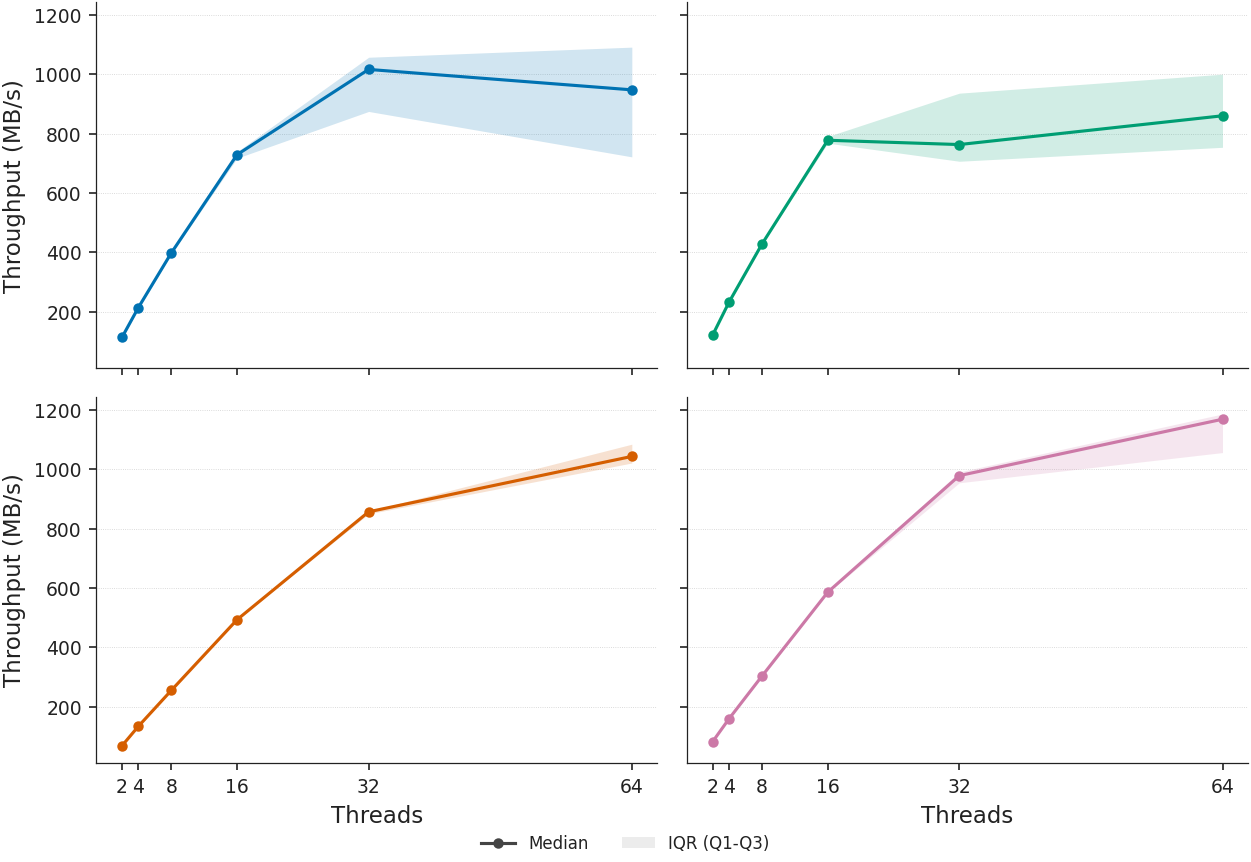

wrote plots/varsized_copy_iqr_q2.pdf


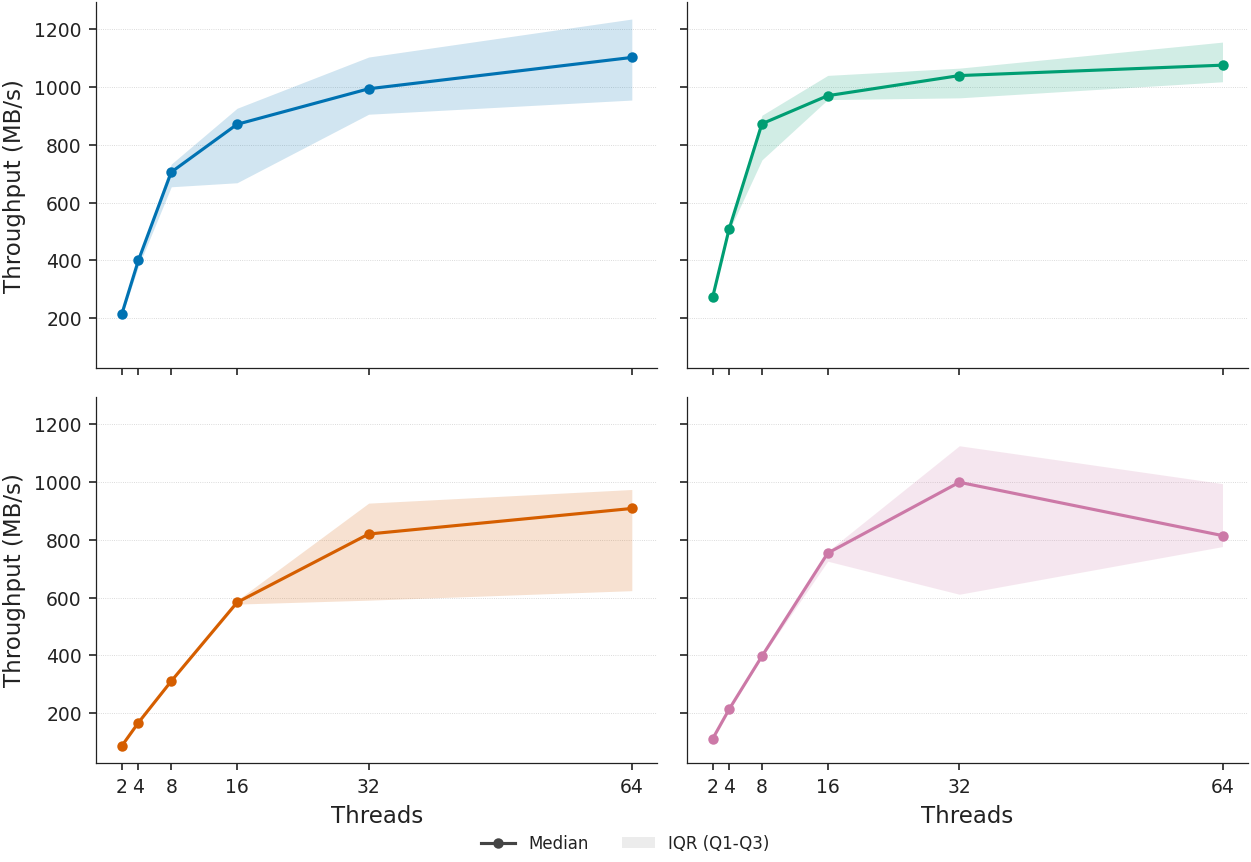

wrote plots/varsized_copy_iqr_q3.pdf


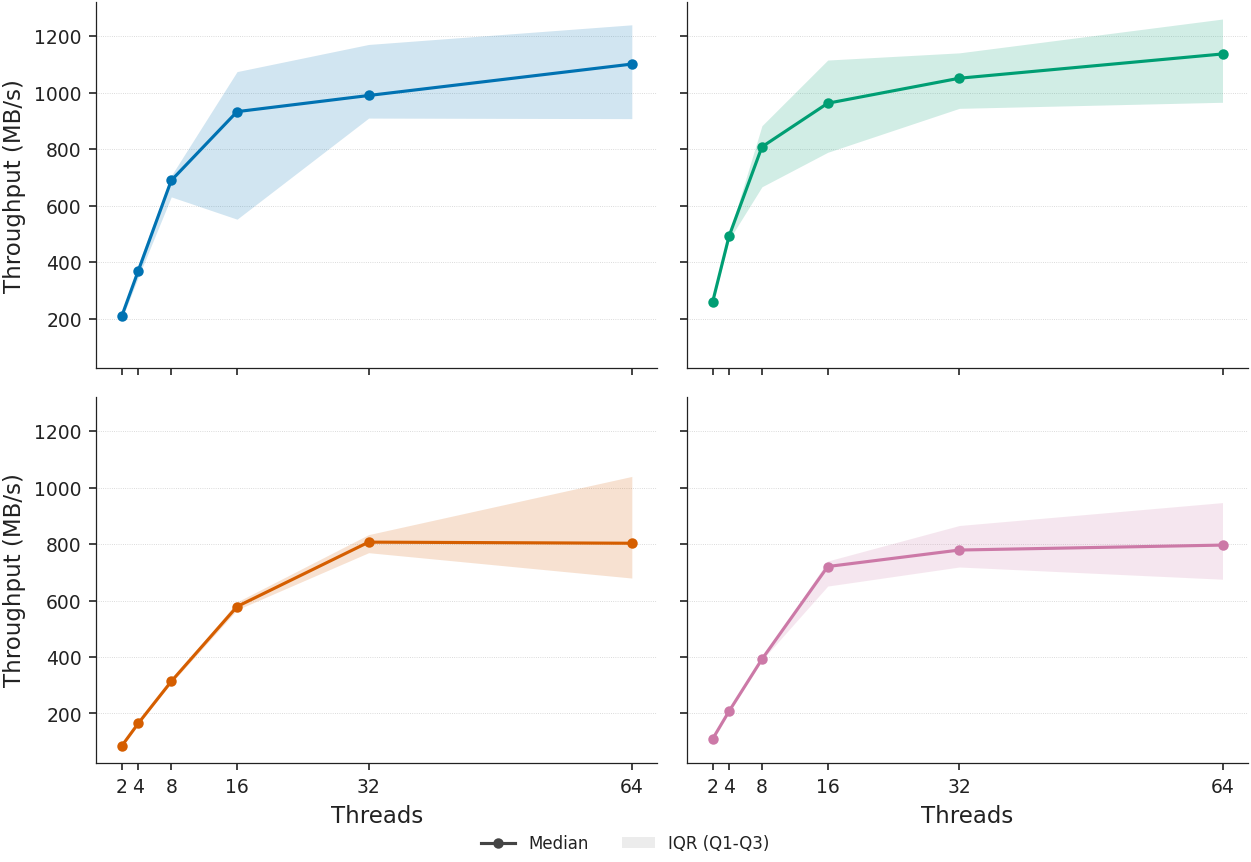

wrote plots/varsized_copy_iqr_q4.pdf


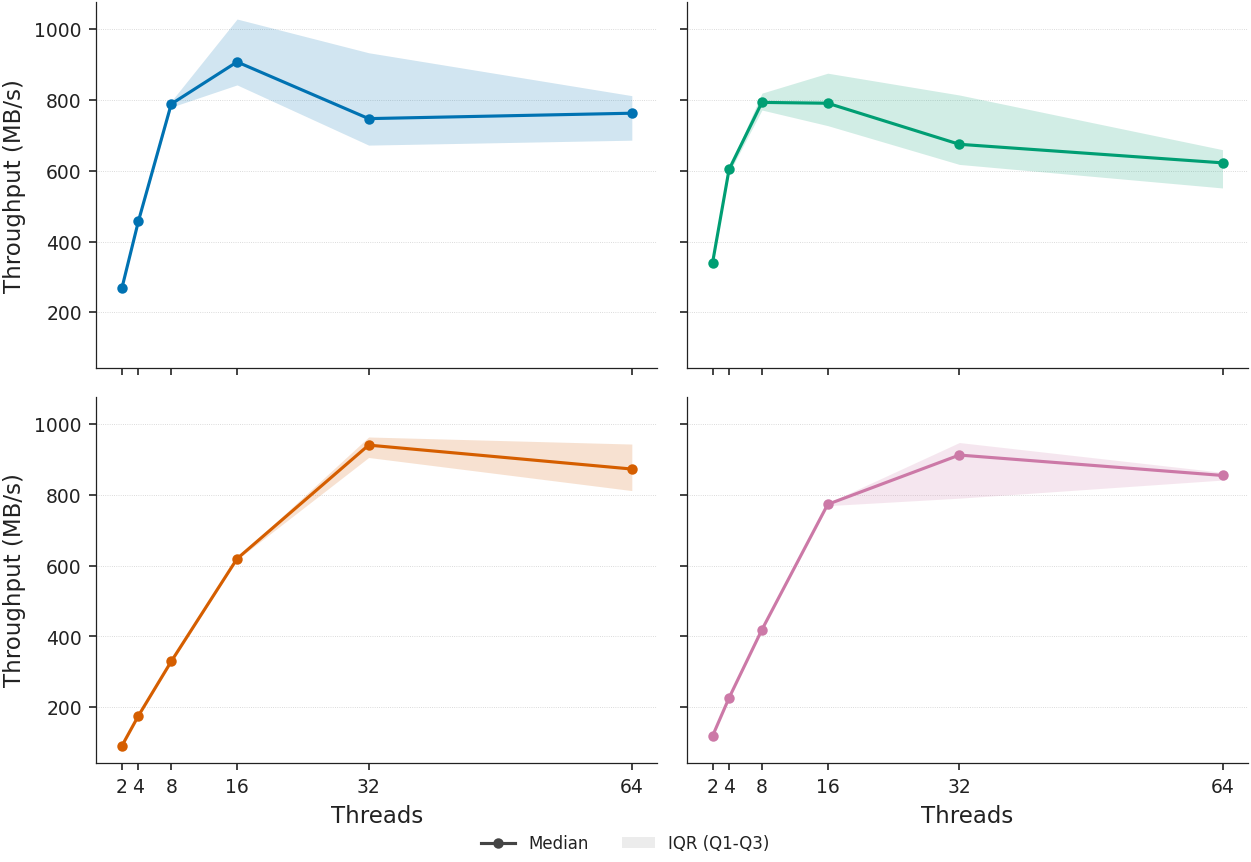

In [89]:
# IQR plot: median throughput with interquartile range over repeated runs
import os
import re
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

thesis_rc = {
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica", "Liberation Sans"],
    "font.size": 10,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "#222222",
    "axes.labelcolor": "#222222",
    "axes.titlecolor": "#222222",
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "axes.labelsize": 11,
    "axes.titlesize": 10,
    "axes.linewidth": 0.6,
    "axes.edgecolor": "#222222",
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "legend.frameon": False,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
}

queries = sorted(df["query"].unique())
query_labels = {q: f"Q{i + 1}" for i, q in enumerate(queries)}
query_file_labels = {
    q: re.sub(r"[^a-z0-9]+", "_", query_labels[q].lower()).strip("_") for q in queries
}
suites = SUITE_ORDER
suite_colors = SUITE_COLORS
thread_counts = sorted(df["threads"].unique())

iqr_stats = (
    df.groupby(["query", "suite", "threads"])["throughput_MBs"]
    .agg(
        q1=lambda s: s.quantile(0.25),
        median="median",
        q3=lambda s: s.quantile(0.75),
    )
    .reset_index()
)

with mpl.rc_context(thesis_rc):
    for q in queries:
        fig, axes = plt.subplots(2, 2, figsize=(8.6, 5.8), sharex=True, sharey=True, squeeze=False)

        for idx, suite in enumerate(suites):
            row, col = divmod(idx, 2)
            ax = axes[row][col]
            subset = (
                iqr_stats[(iqr_stats["query"] == q) & (iqr_stats["suite"] == suite)]
                .set_index("threads")
                .reindex(thread_counts)
            )

            x = np.array(thread_counts)
            y = subset["median"].to_numpy(dtype=float)
            q1 = subset["q1"].to_numpy(dtype=float)
            q3 = subset["q3"].to_numpy(dtype=float)

            ax.fill_between(x, q1, q3, color=suite_colors[suite], alpha=0.18, linewidth=0)
            ax.plot(
                x,
                y,
                marker="o",
                markersize=4.0,
                linewidth=1.5,
                color=suite_colors[suite],
            )

            ax.set_xticks(thread_counts)
            ax.grid(True, axis="y", linestyle=":", linewidth=0.4, alpha=0.6, zorder=0)
            ax.set_axisbelow(True)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            if row == 1:
                ax.set_xlabel("Threads")
            if col == 0:
                ax.set_ylabel("Throughput (MB/s)")

        median_handle = plt.Line2D([0], [0], color="#444444", marker="o", linewidth=1.5, markersize=4.0, label="Median")
        iqr_handle = mpl.patches.Patch(facecolor="#999999", alpha=0.18, edgecolor="none", label="IQR (Q1-Q3)")
        fig.legend([median_handle, iqr_handle], ["Median", "IQR (Q1-Q3)"], loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.02))
        fig.tight_layout()

        out = os.path.join(PLOTS_DIR, f"varsized_copy_iqr_{query_file_labels[q]}.pdf")
        fig.savefig(out)
        print(f"wrote {out}")
        plt.show()
